In [1]:
import numpy as np
import os
from micado_misthic import misthic_func
from configobj import ConfigObj
from micado_misthic.utils.obsparams import * 
from astropy.table import Table
import matplotlib as mpl
import pandas as pd
import math

### Main directory of the repos
repository_dir              = 'C:/Users/Red Slottje/Documents/micado_misthic'

### directory with flux & transmission data for MICADO
flux_dir                    = repository_dir + '/flux_data/'

### directories with the coronagraphic simulated images
all_coro_sim_dir_prefix     = 'D:/FROM_RED/coro_sims/'

### directories to record the processed data
record_dir_prefix     = 'D:/FROM_RED/coro_adi_new/ADI/'


###-- Observation params
coronagraph     = 'CLC1' # 'CLC0' or 'CLC1'
quartile        = 'Q1'#['Q1', 'Q4', 'MED']
keyword_NCPA    = 'NoNCPA' 
lbd             = 1.582 # Choose filter
p_dist_mas      = 13.052
duree = [60.0]
pixscale_in_mas = 1.5 # 1.5 or 4 mas

coro_sim_dir         = all_coro_sim_dir_prefix + f'{coronagraph}_{quartile}_NoNCPA/lambda={lbd:5.3f}/p_dist_mas={p_dist_mas}/TURBU_ABERR/duree={duree[0]}min/'
#coro_resized_dir    =  record_dir_prefix + f'D:\FROM_RED\resized_fft_coro\CLC1_Q1_noNCPA\lbd={lbd}_pxscale={pixscale_in_mas}'
coro_resized_dir = record_dir_prefix
planet_resized_dir = record_dir_prefix+'PLANET/'

### path to the configspec file (same as the misthic_func.py module)
configspec_file   = os.path.dirname(misthic_func.__file__)+'/misthic_configspec.ini'

### Read infos from the .ini file of the directory to process
ini_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('.ini')][0]
config  = ConfigObj(coro_sim_dir+ini_file, configspec=configspec_file)
detector_sampling = np.float32(config['detectorconfig']['detector_sampling']) ## Sampling for initial simulation
frame_exp_time  = np.float32(config['simuconfig']['delta_t']) ## exposure time per frame in seconds 


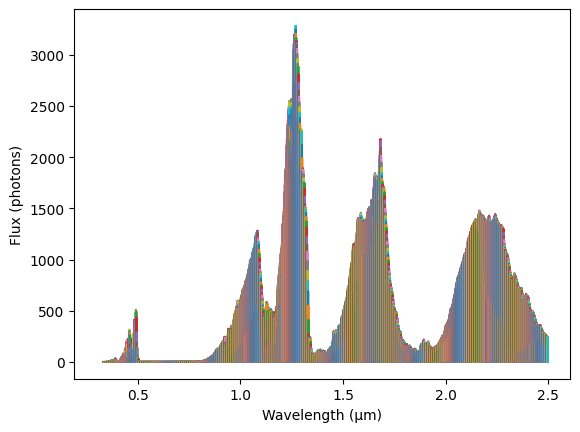

In [2]:
spec_dir = 'C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/'
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
temp = np.arange(200, 1000, 50)
r_pl    = 1
dist_pc = 39.4
airmass = 1.
telescope_pupil_file        = f'D:/FROM_NELLIE/INPUT_fromNellie/PUPIL/Pupil_ELT_v03.fits'
planet_flux_list = []
spec_wave_list = []
planet_photon_flux_list = []

telescope_surface = get_aperture_surface(telescope_pupil_file)
#_, star_flux = get_star_spectrum(flux_dir, star_mag, lbd[0])
for i in range(len(temp)):
    for j in range(len(logg)):
        for k in range(len(metallicity)):
            for l in range(len(CO)):
                if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg[j]}_met{metallicity[k]}_CO{CO[l]}.dat' != 0 :
                    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, flux_dir=flux_dir)
                    planet_flux_list.append(planet_flux)
                    spec_wave_list.append(spec_wave)
                else : 
                    continue

#C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/spectra_YGP_450K_logg4.0_met1.00_CO0.75.dat not found. (CO0.75 missing)    

#some of them are missing ; must be in the missing gridpoints grid


# met{metallicity:.2f}_CO{CO:3.2f}
plt.plot(spec_wave_list,planet_flux_list)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux (photons)')
plt.show()

# photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, star_flux, f'{lbd[0]:5.3f}', 
#                                                                      frame_exp_time, telescope_surface, 
#                                                                      airmass=airmass, pixel_scale=pixscale_in_mas)


In [3]:
# writing the parameters to a fits file 

# metallicity = np.array([0.32, 1.00, 3.16, 10.00, 31.62, 100.00])
# temp = np.arange(200, 2000, 50)
# logg = np.array([3.0, 3.5, 4.0, 4.5, 5.0])
# CO =  np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70])
# lbd = np.array([1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145])

metacube = { 'metallicity' : np.array([0.32, 1.00, 3.16, 10.00, 31.62, 100.00]), 
                'temp' : np.arange(200, 2000, 50),
                'logg' : np.array([3.0, 3.5, 4.0, 4.5, 5.0]),
                'CO' :  np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]),
                'lbd' : np.array([1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145])}
# col1 = fits.Column(name= 'Metallicity', format = 'E', array = metallicity)
# col2 = fits.Column(name = 'Temperature', format = 'E', array = temp)
# col3 = fits.Column(name = 'logg', format = 'E', array = logg)
# col4 = fits.Column(name = 'CO', format = 'E',  array = CO)
# col5 = fits.Column(name = 'Wavelength', format = 'E', array = lbd)

# fits_header = fits.Header()
# fits_header['INFO'] = "Planet physical parameters : contains metallicity, temperature, logg, CO and wavelength filters for MICADO. Created to simplify parameter handling in simulations."
# primary_HDU = fits.PrimaryHDU(header = fits_header)
# metallicity_HDU = fits.BinTableHDU.from_columns(fits.ColDefs([col1]))
# temperature_HDU = fits.TableHDU.from_columns(fits.ColDefs([col2]))
# logg_HDU = fits.TableHDU.from_columns(fits.ColDefs([col3]))
# CO_HDU = fits.TableHDU.from_columns(fits.ColDefs([col4]))
# wavelength_HDU = fits.TableHDU.from_columns(fits.ColDefs([col5]))

#hdu_list = fits.HDUList([primary_HDU, metallicity_HDU, temperature_HDU, logg_HDU, CO_HDU, wavelength_HDU])


#fits.writeto('physical_planet_parameters_storage.fits', metacube)

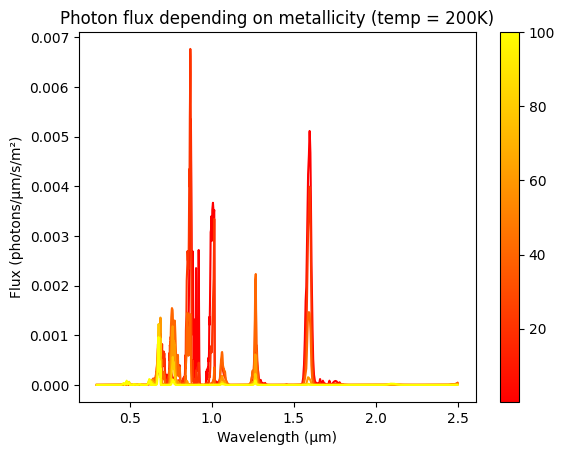

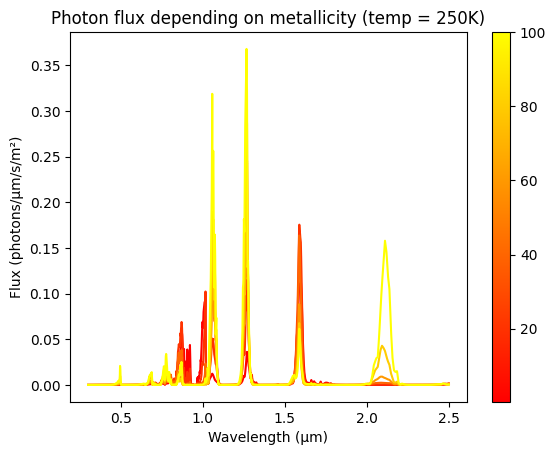

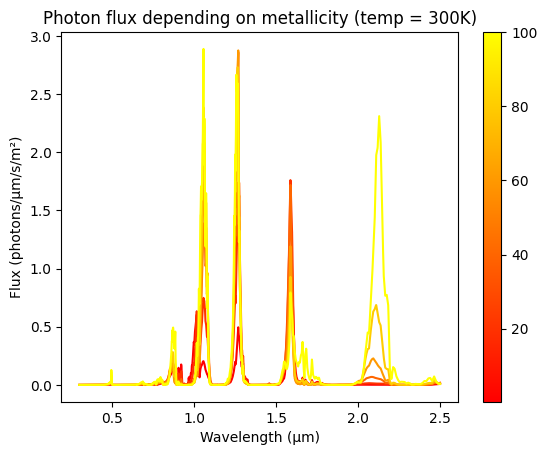

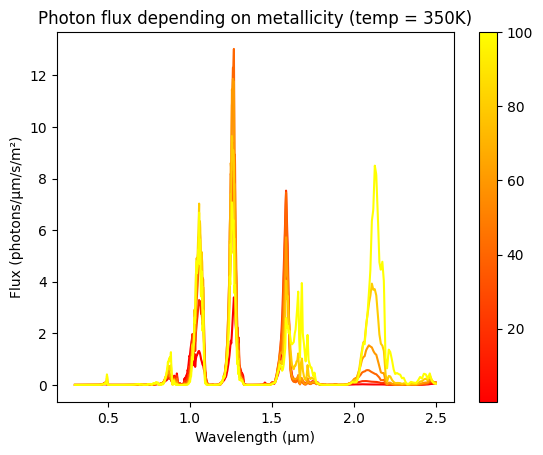

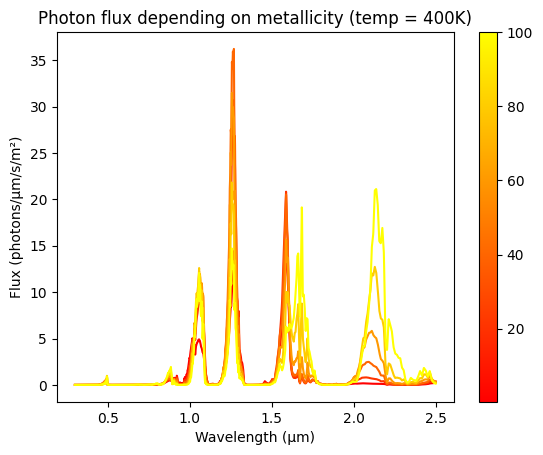

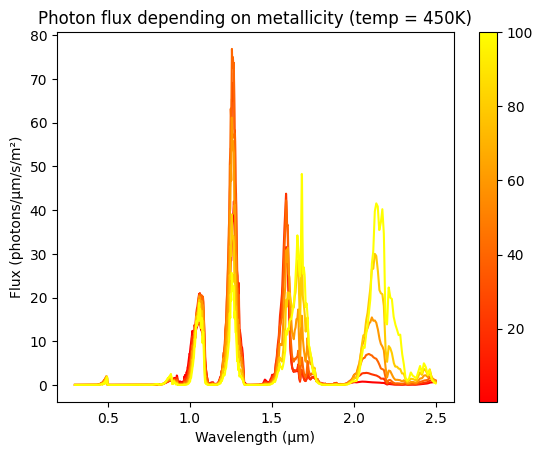

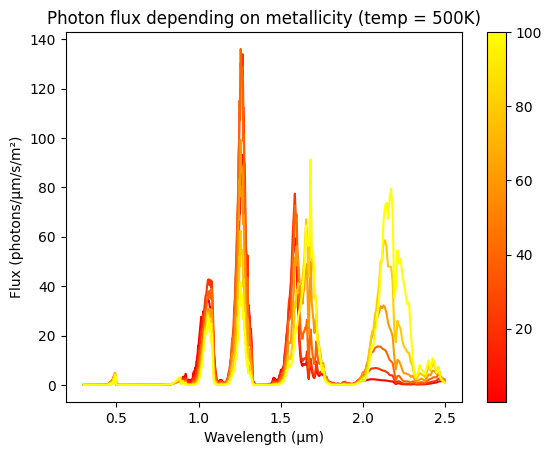

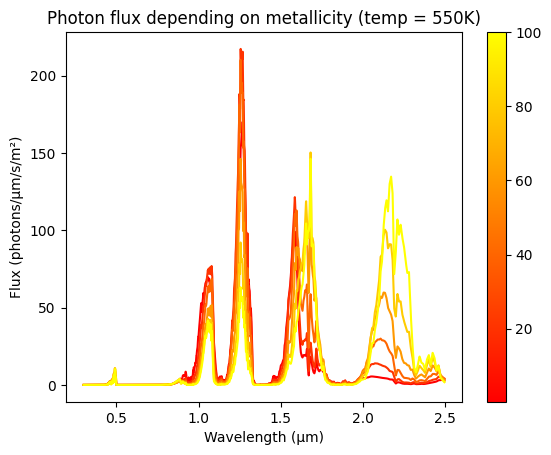

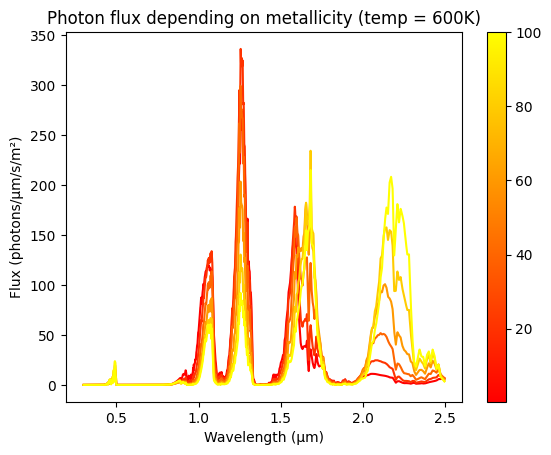

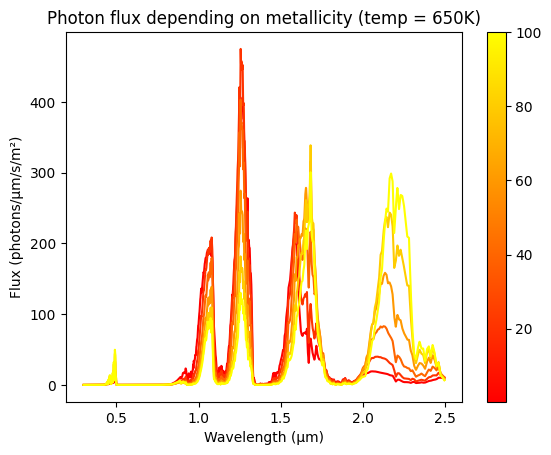

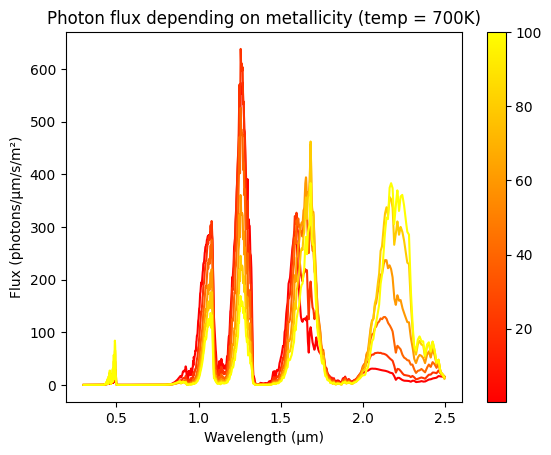

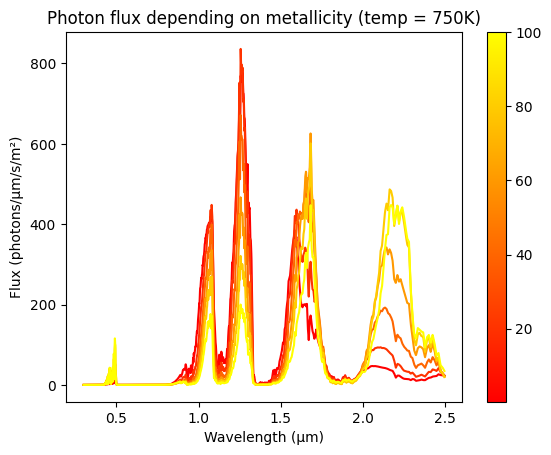

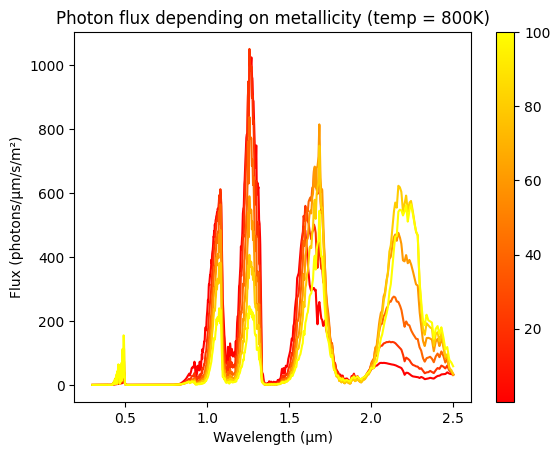

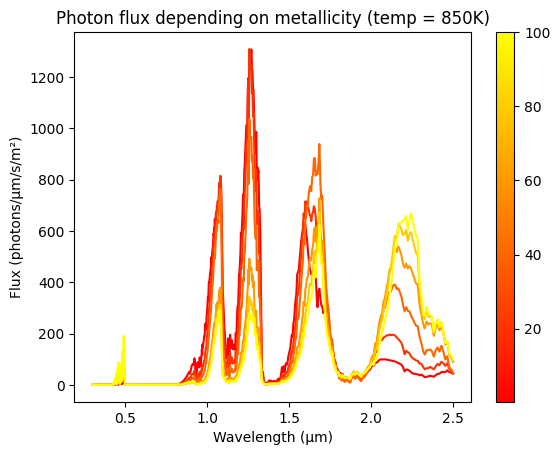

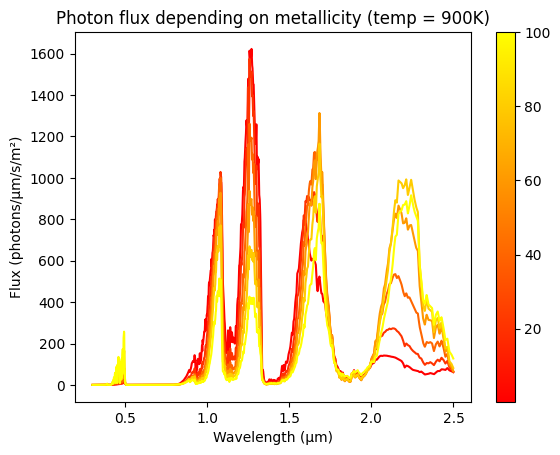

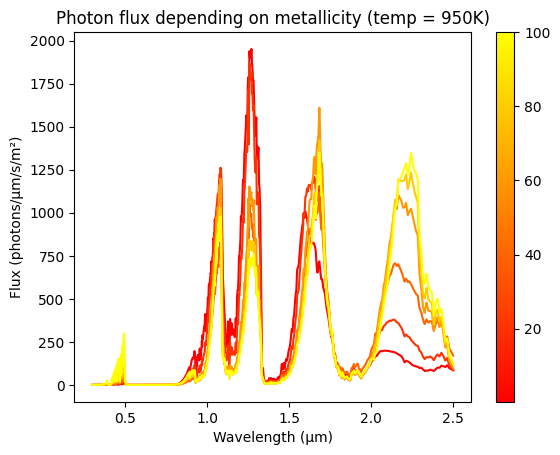

In [4]:
# metallicity with fix temp
# Output : one figure per temperature with one plot per metallicity in each

metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
temp = np.arange(200, 1000, 50)
logg = 3.5
CO = 0.25

# setting up the color coding of the plots
n = len(metallicity)
colors = plt.cm.autumn(np.linspace(0,1,n))

# setting up the colorbar
c = np.array(metallicity)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

for j in range(len(temp)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(metallicity)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[j], logg, metallicity[k], CO, dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color=colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on metallicity (temp = {temp[j]}K)')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/µm/s/m²)')
    plt.show()


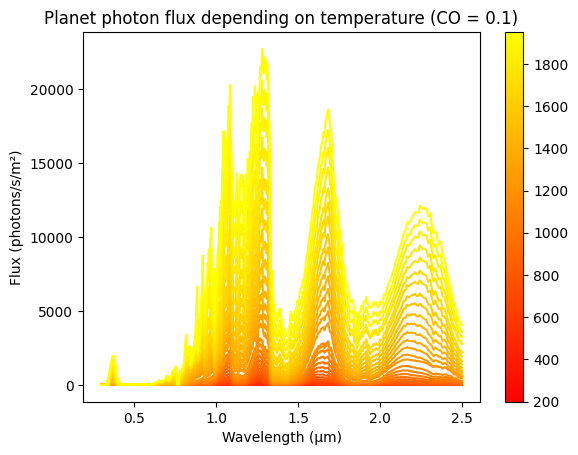

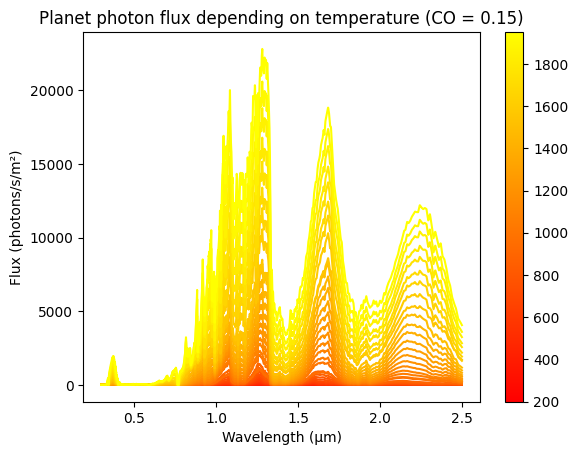

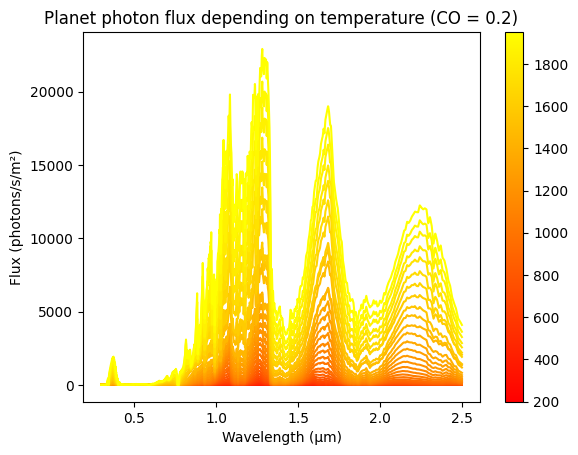

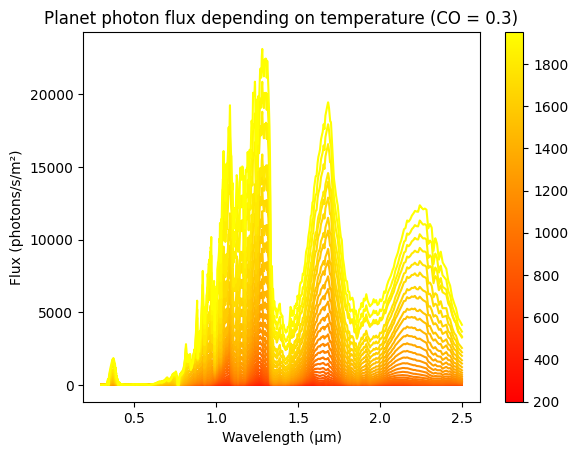

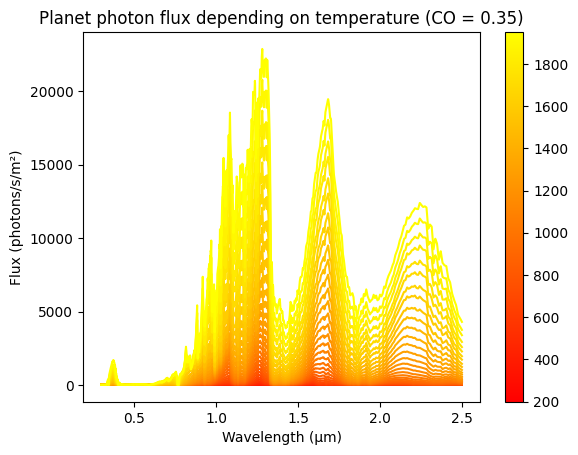

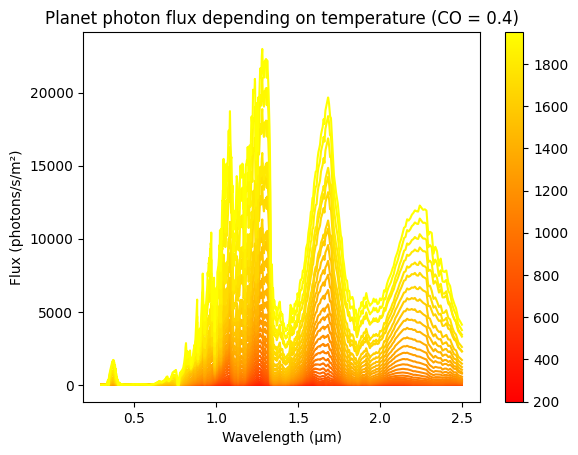

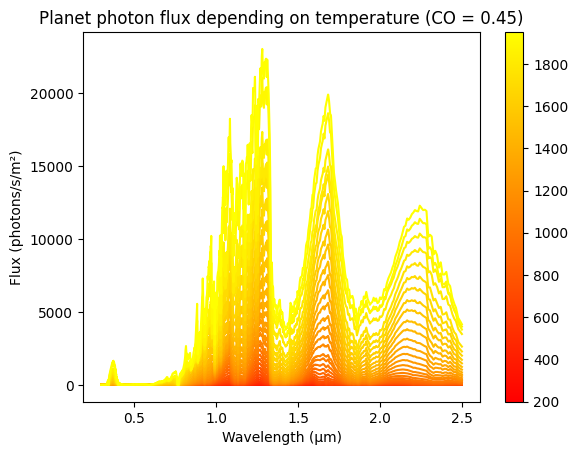

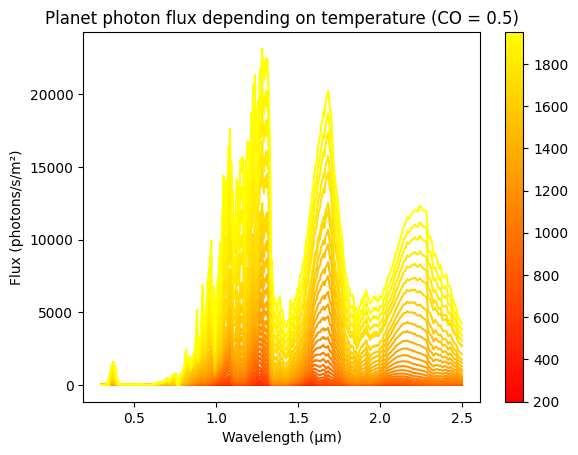

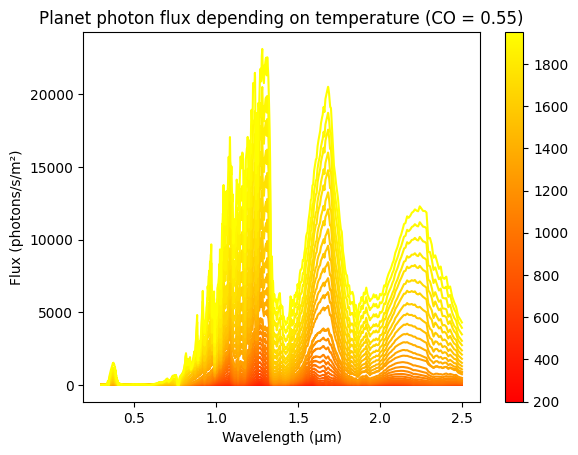

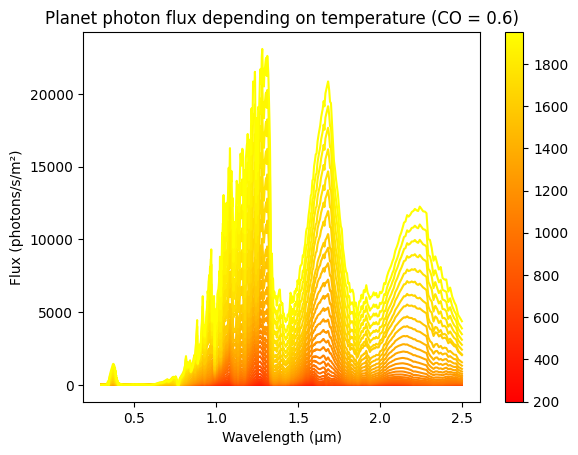

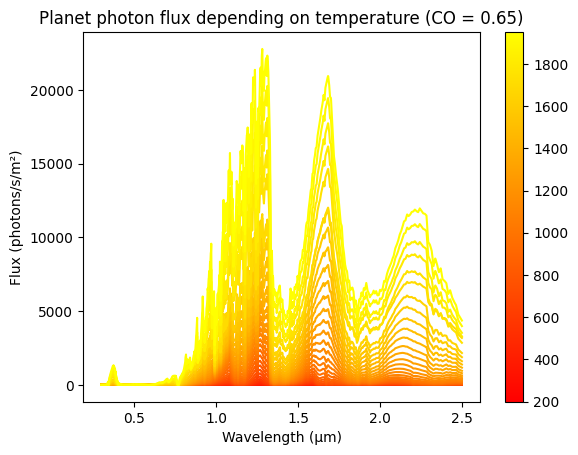

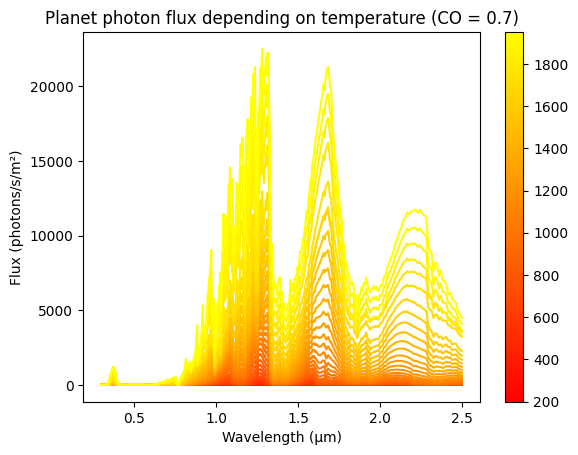

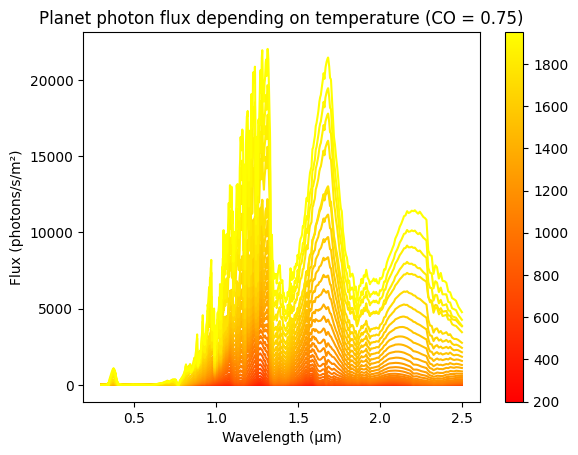

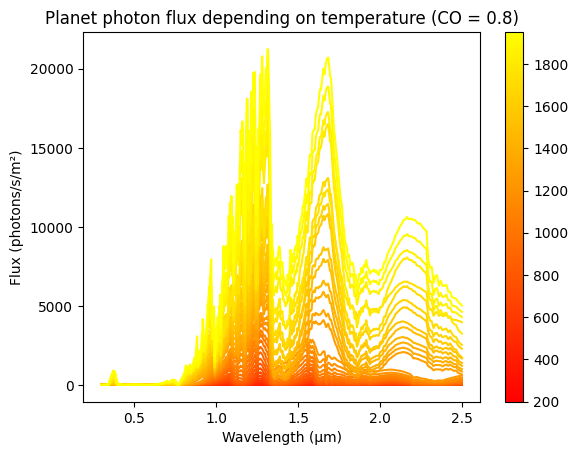

In [5]:
#temp with fix CO
# Output : one figure per CO with a plot per temperature in each

metallicity = 1.0
temp = np.arange(200, 2000, 50)
logg = 3.5
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

n = len(temp)
colors = plt.cm.autumn(np.linspace(0,1,n))

c = temp
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

for j in range(len(CO)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(temp)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO[j], dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Planet photon flux depending on temperature (CO = {CO[j]})')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()

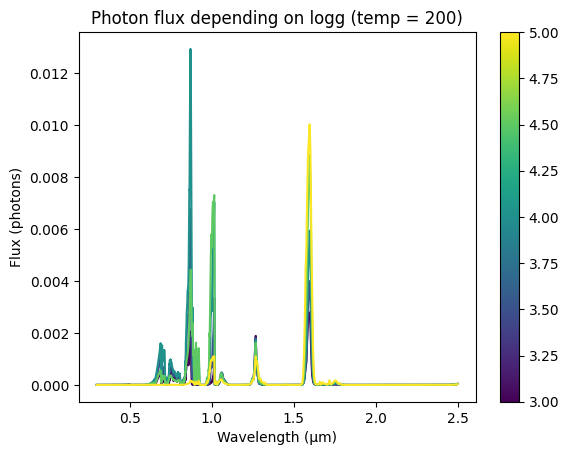

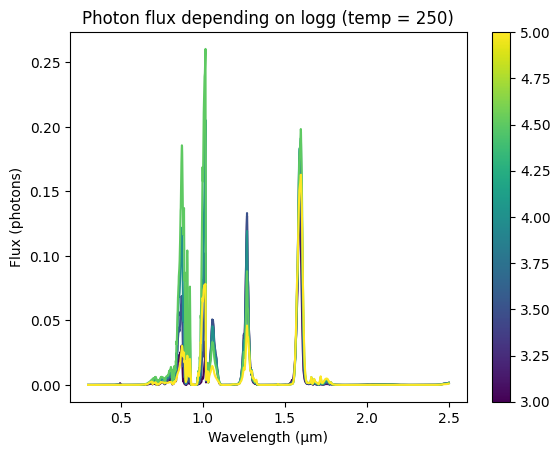

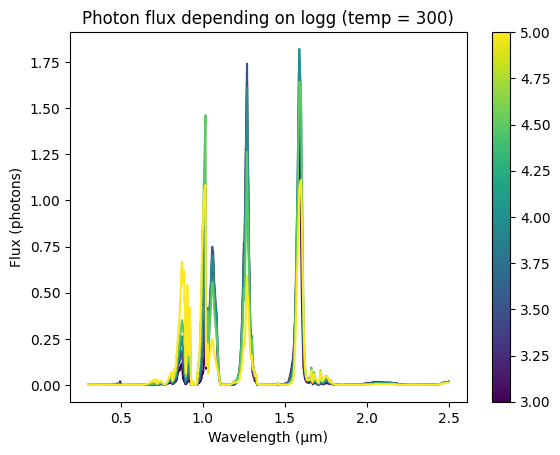

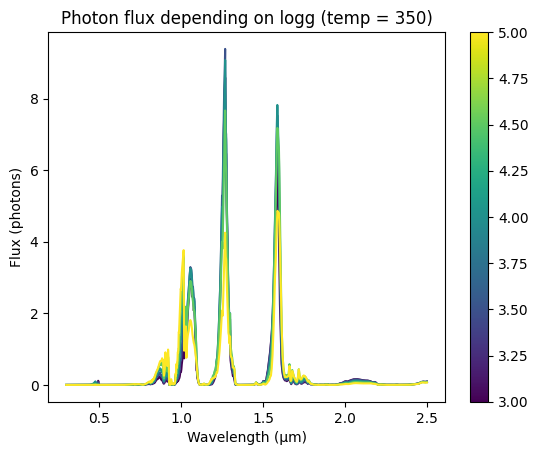

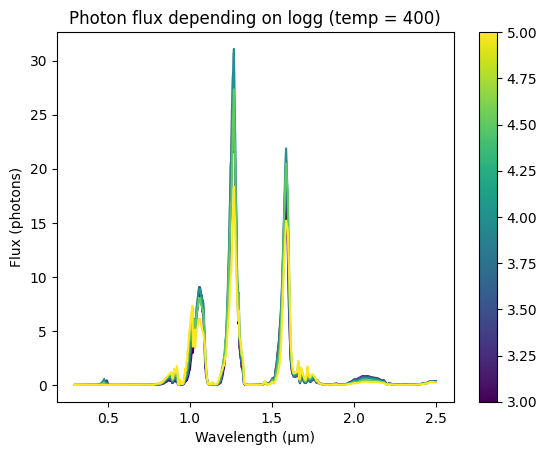

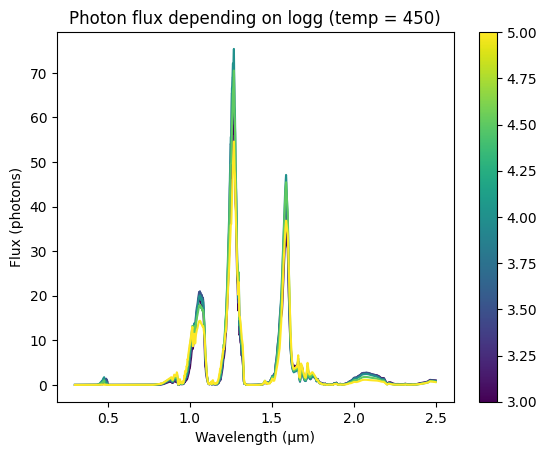

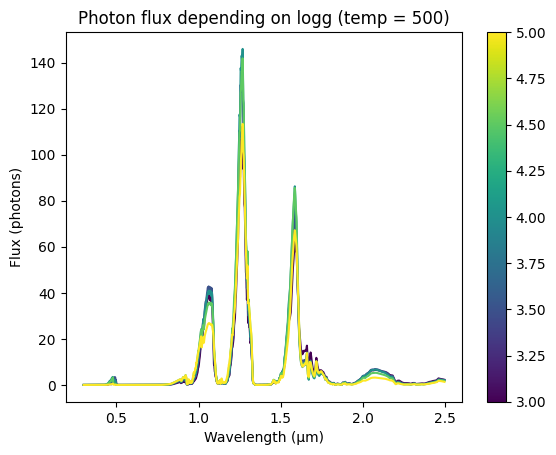

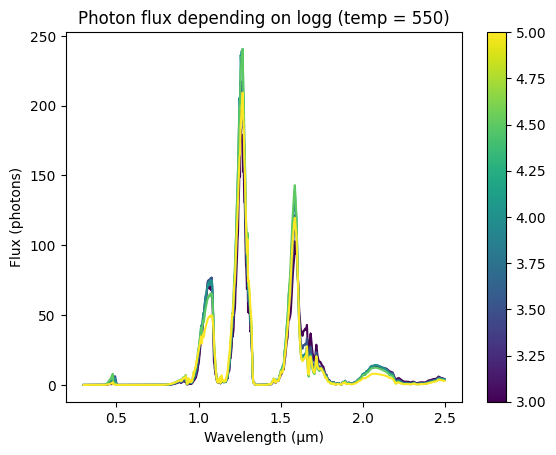

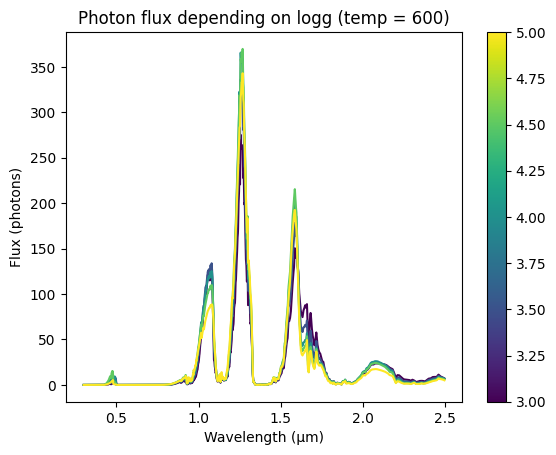

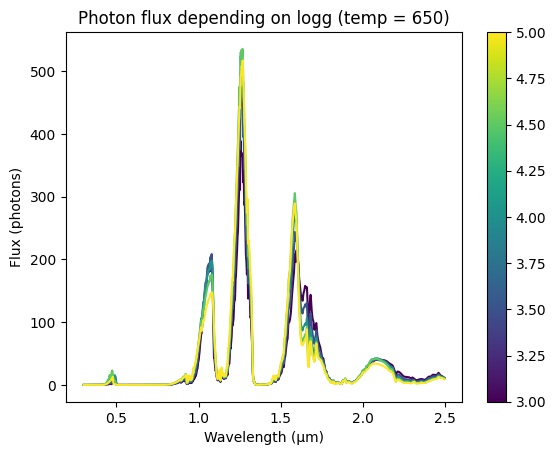

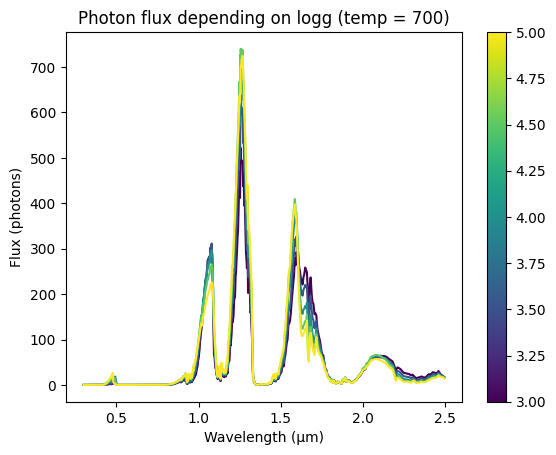

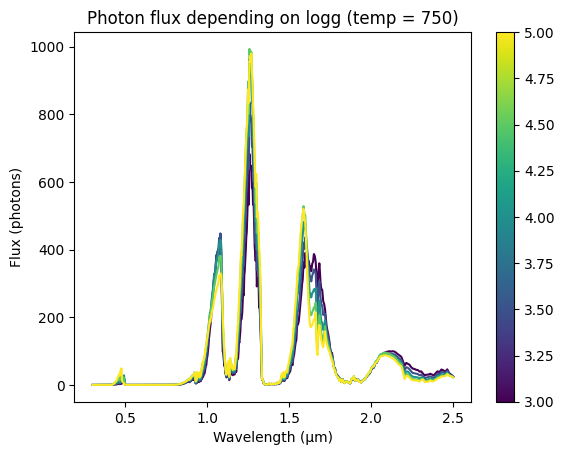

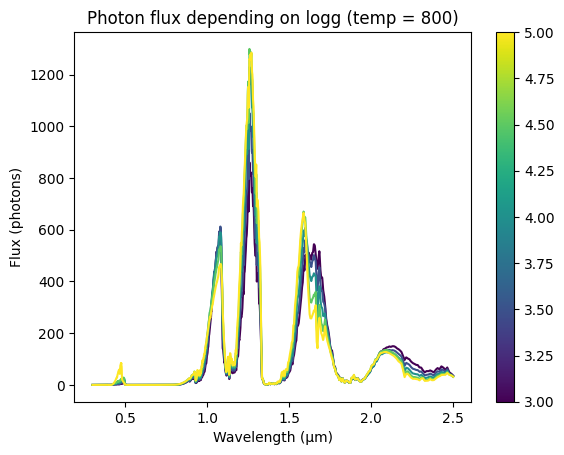

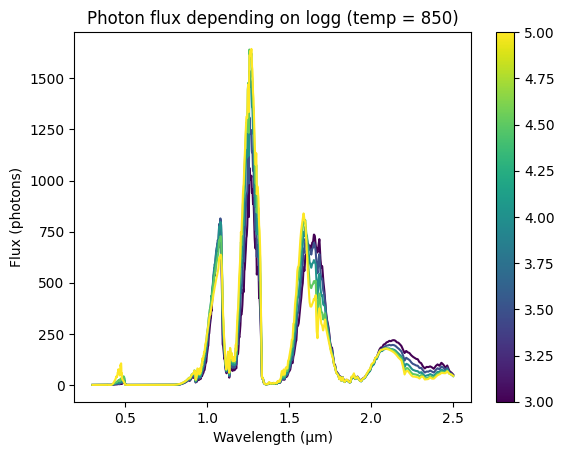

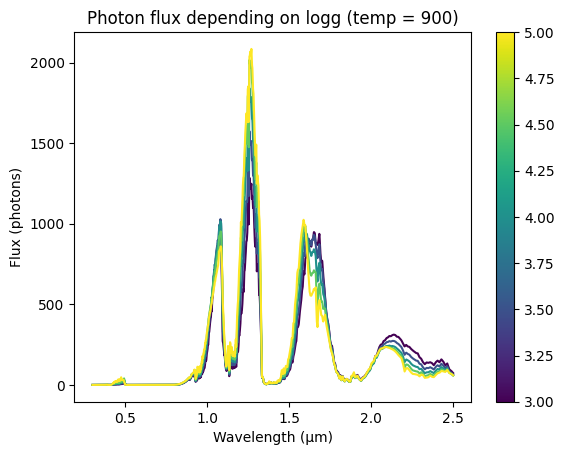

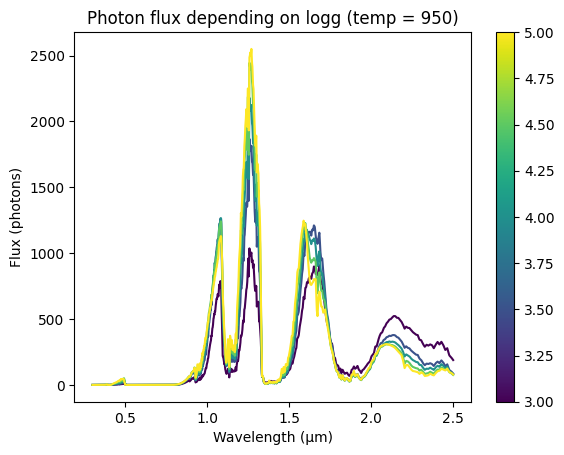

In [6]:
# logg with fix temp
metallicity = 1.00
temp = np.arange(200, 1000, 50)
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
CO = 0.25

n = len(logg)
colors = plt.cm.viridis(np.linspace(0,1,n))

c = np.array(logg)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

for j in range(len(temp)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(logg)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[j], logg[k], metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on logg (temp = {temp[j]})')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons)')
    plt.show()

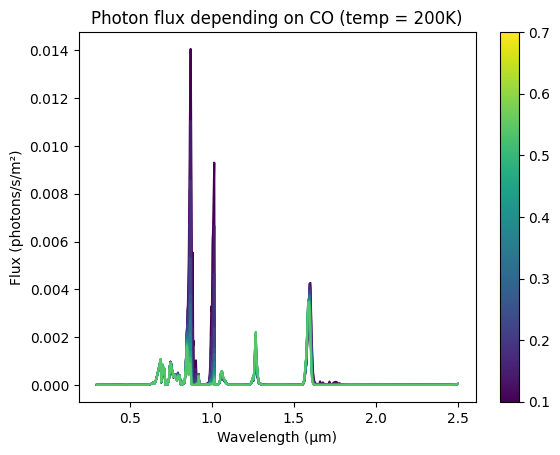

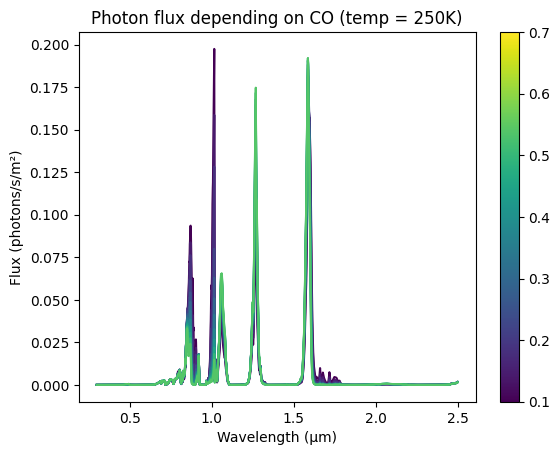

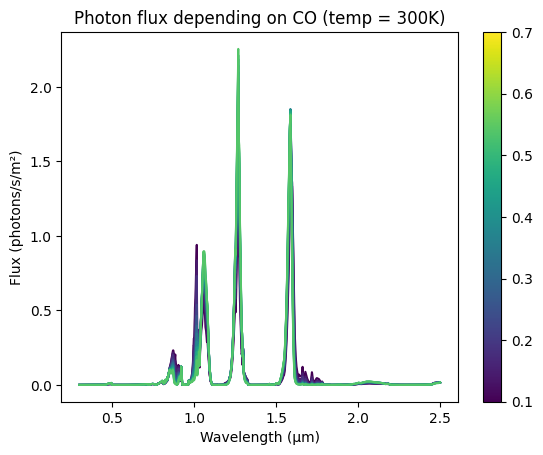

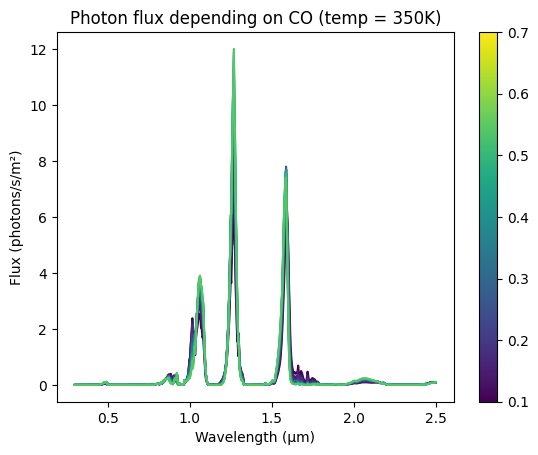

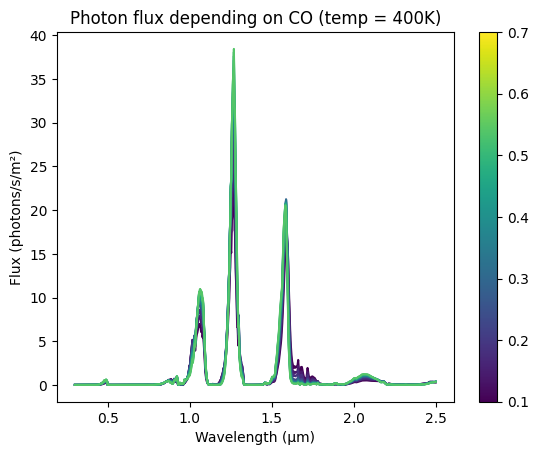

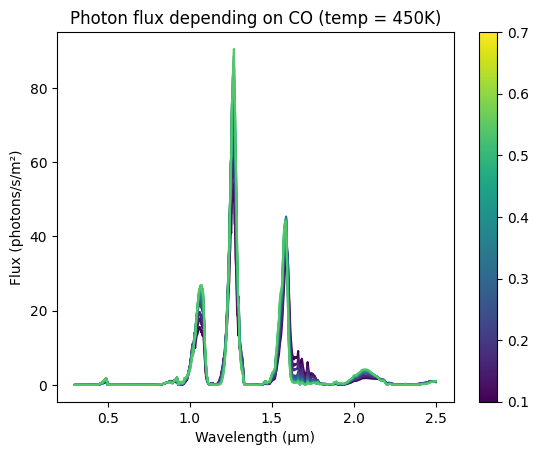

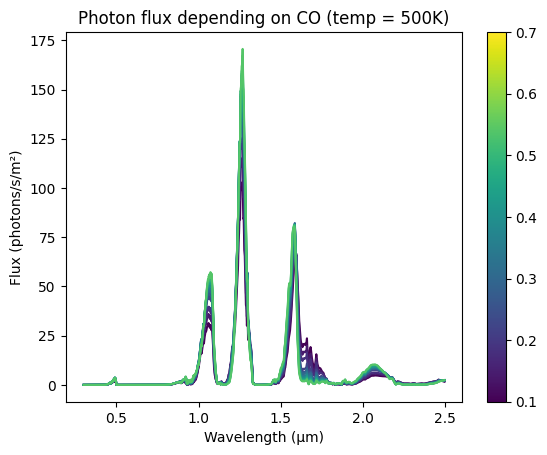

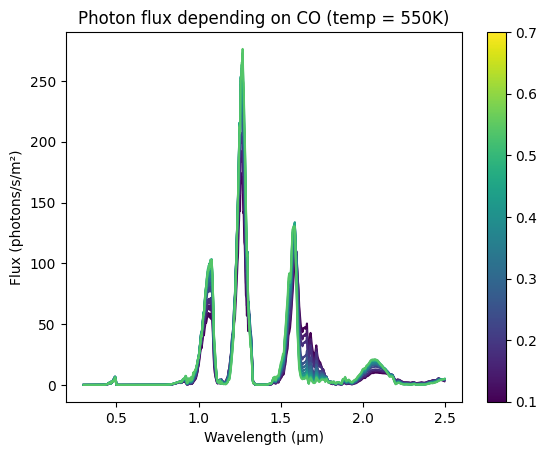

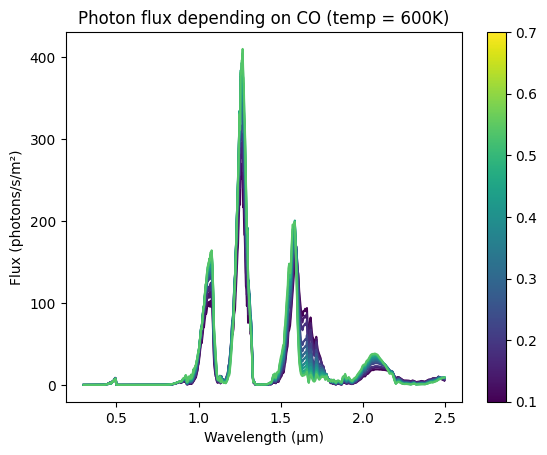

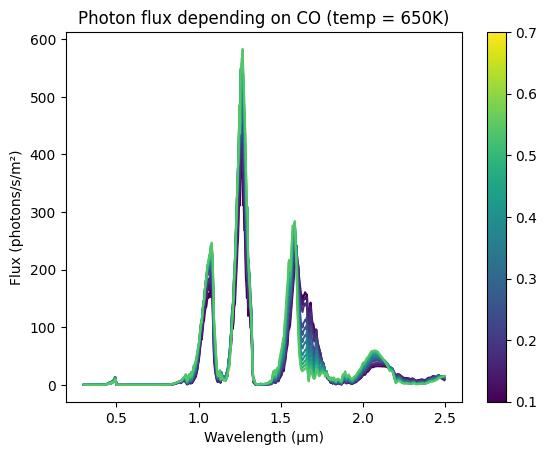

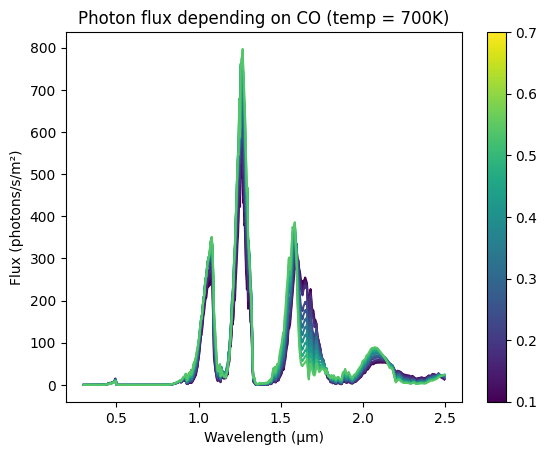

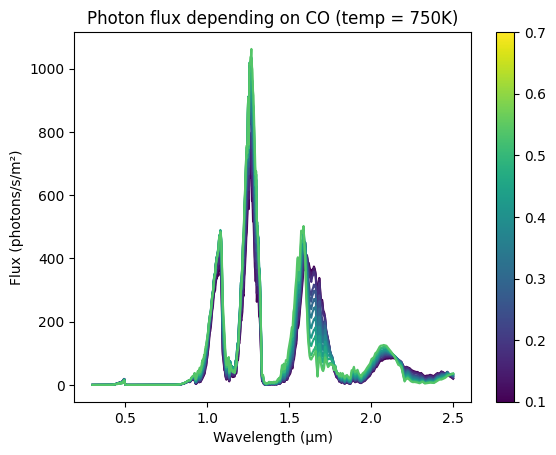

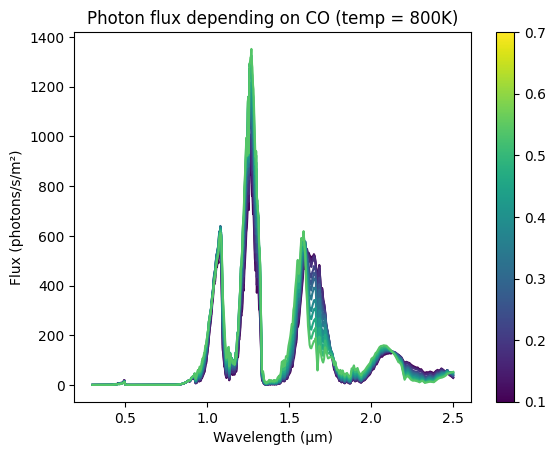

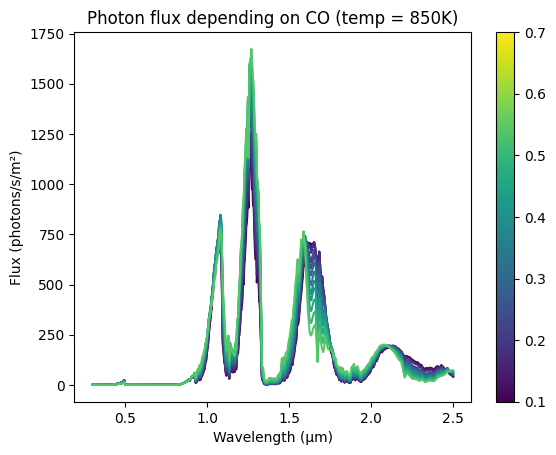

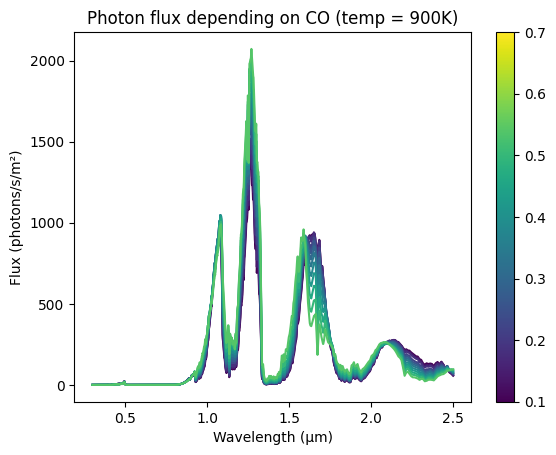

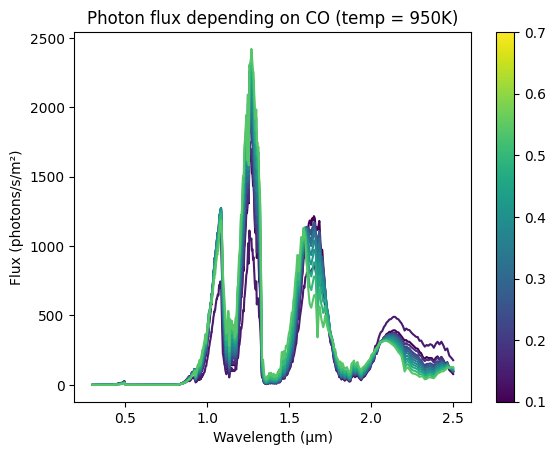

In [7]:
# CO with fix temp
metallicity = 1.00
temp = np.arange(200, 1000, 50)
logg = 3.5
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

n = len(temp)
colors = plt.cm.viridis(np.linspace(0,1,n))

c = np.array(CO)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

for j in range(len(temp)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(CO)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[j], logg, metallicity, CO[k], dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on CO (temp = {temp[j]}K)')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()

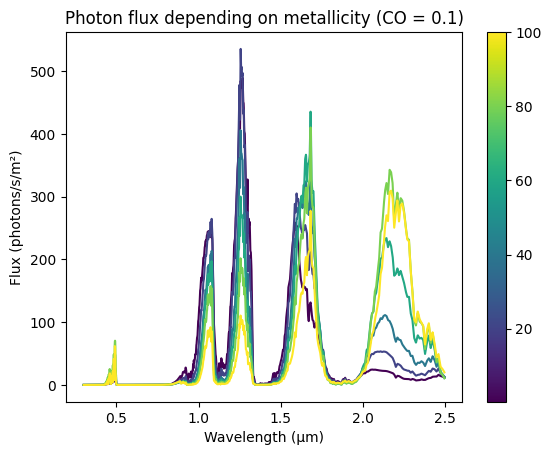

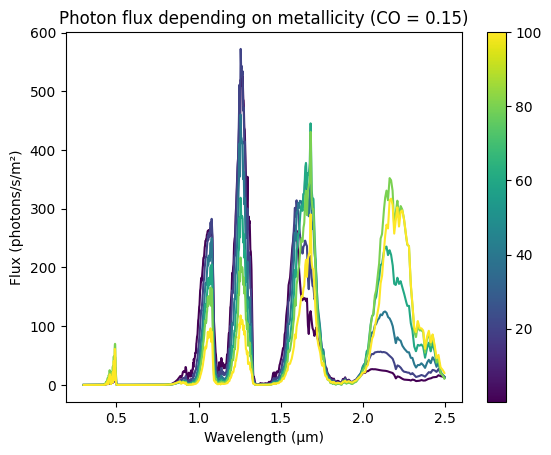

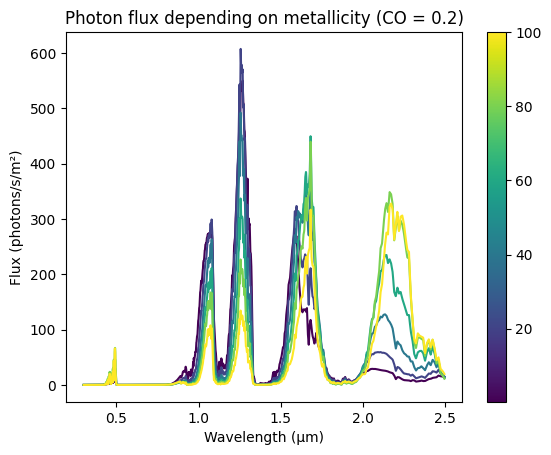

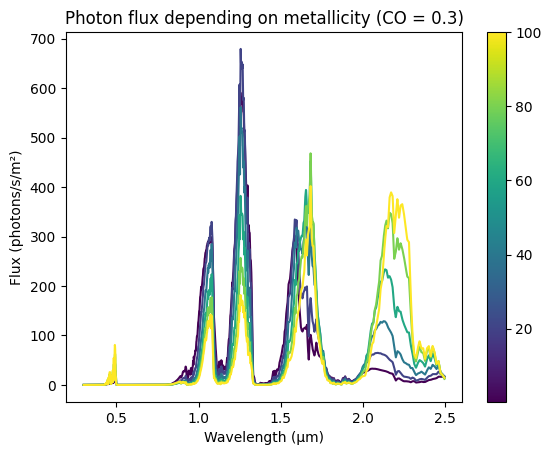

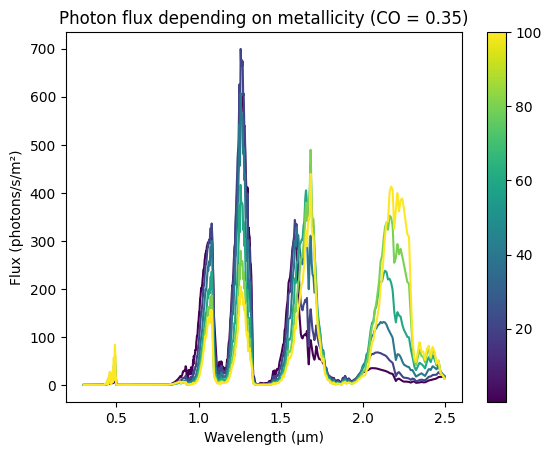

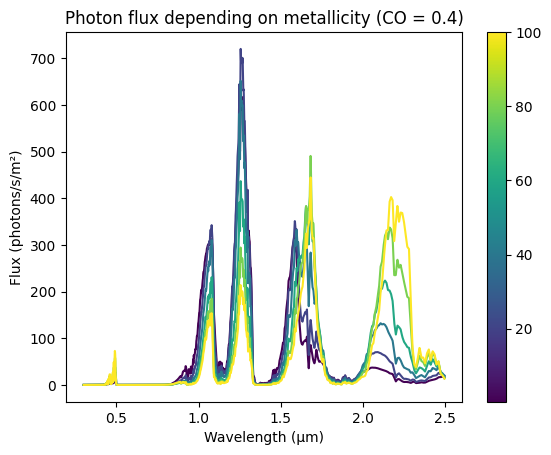

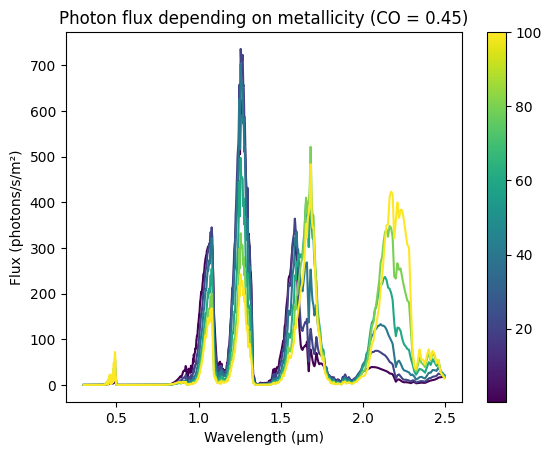

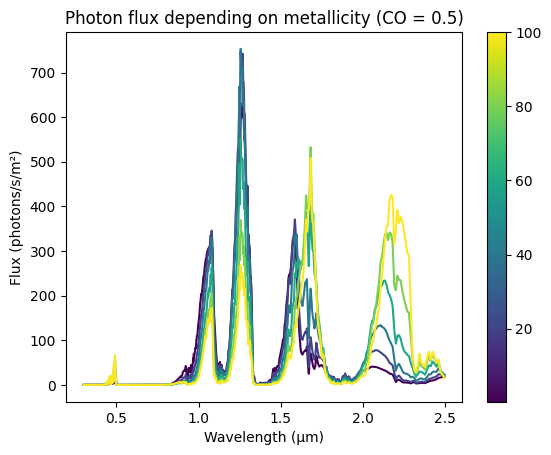

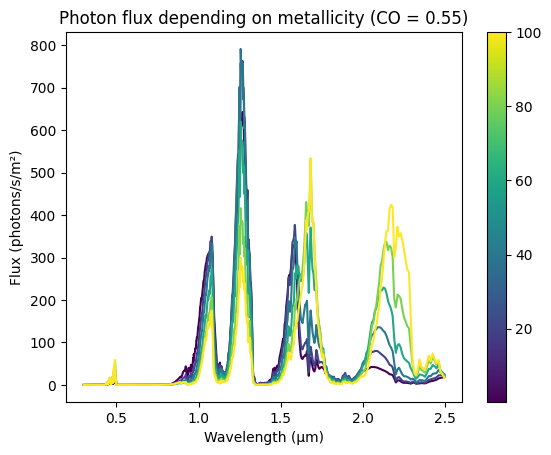

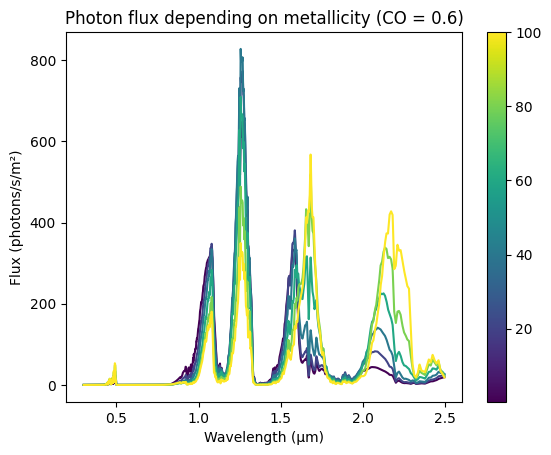

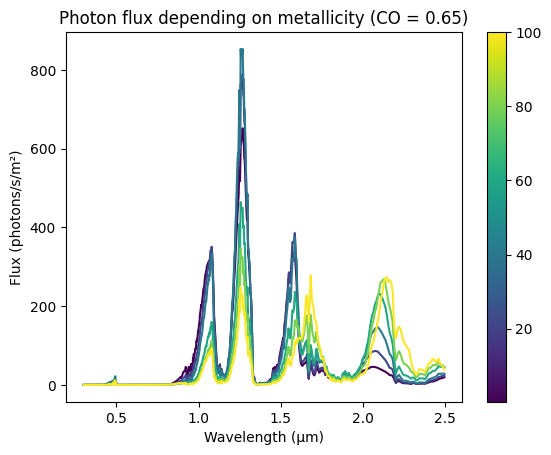

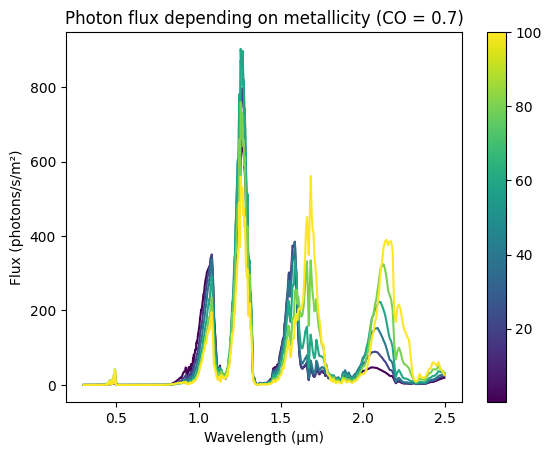

In [8]:
#metallicity with fixed CO
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
temp = 700
logg = 3.5
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

c = np.array(metallicity)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

n = len(metallicity)
colors = plt.cm.viridis(np.linspace(0,1,n))
for j in range(len(CO)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(metallicity)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity[k], CO[j], dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on metallicity (CO = {CO[j]})')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()


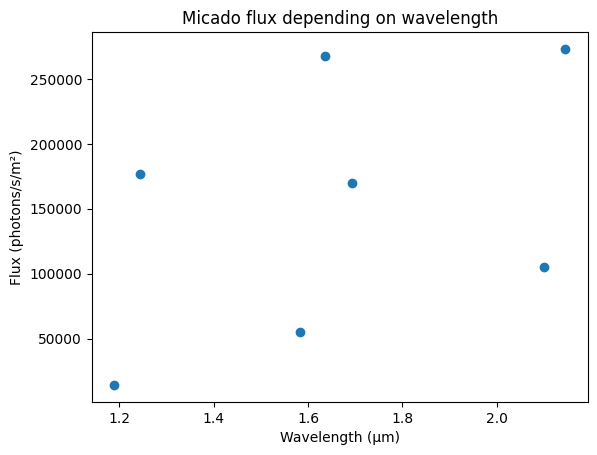

In [9]:
#micado flux depending on wavelength
lbd = [1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145]
lbd_broadband = [1.245, 1.635, 2.145]
planet_photon_flux_list = []

for i in range(len(lbd)):
    planet_photon_flux, planet_emission_per_pix, planet_global_transmission = get_micado_flux(flux_dir, 
                                                                             planet_flux, f'{lbd[i]:5.3f}', 
                                                                             frame_exp_time, telescope_surface, 
                                                                             airmass=airmass, pixel_scale=pixscale_in_mas)
    planet_photon_flux_list.append(planet_photon_flux)

plt.scatter(lbd, planet_photon_flux_list)
plt.title('Micado flux depending on wavelength')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux (photons/s/m²)')
plt.show()

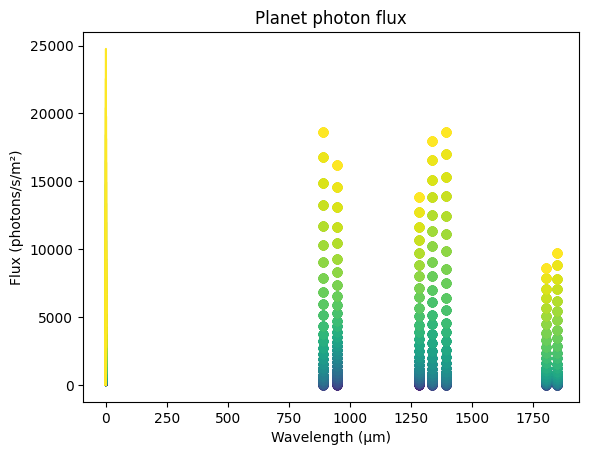

In [10]:
# Planet flux
# What is happenign here. 
metallicity = 0.32 #[0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
temp = np.arange(200, 2000, 50)
logg = 3.5
CO =  0.50 #[0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
lbd = [1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145]
lbd_broadband = [1.245, 1.635, 2.145]
planet_photon_flux_list = []
planet_flux_list = []
lbd_contrast_index = []
#planet_flux_list_plot = []

n = len(temp)
colors = plt.cm.viridis(np.linspace(0,1,n))

#for j in range(len(CO)):
for k in range(len(temp)):
    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)
    planet_flux_list.append(planet_flux)

    plt.plot(spec_wave, planet_flux, color = colors[k])


    for i in range(len(spec_wave)):
        for j in range(len(lbd)):
            if spec_wave[i] == lbd[j] :

                lbd_contrast_index.append(i)
                
    planet_flux_list_plot = []
    for i in lbd_contrast_index :
        planet_flux_list_plot.append(planet_flux[i])
    #print('len planet_flux_list_plot = ', len(planet_flux_list_plot))

    plt.scatter(lbd_contrast_index, planet_flux_list_plot, color = colors[k], marker = "o")
plt.title('Planet photon flux')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux (photons/s/m²)')
#plt.xlim(1.150, 2.250)
plt.show()


List of characterized temperatures :  [33300 31900 31400 29000 26000 24500 20600 18500 17000 16400 15700 14500
 14000 12300 10700 10400  9700  9300  8800  8600  8250  8100  7910  7760
  7590  7400  7220  7020  6820  6750  6670  6550  6350  6280  6180  6050
  5990  5930  5860  5770  5720  5680  5660  5600  5550  5480  5380  5270
  5170  5100  4830  4600  4440  4300  4100  3990  3930  3850  3770  3660
  3620  3560  3470  3430  3270  3210  3110  3060  2930  2810  2740  2680
  2630  2570  2420  2380  2350  2270  2160  2060]


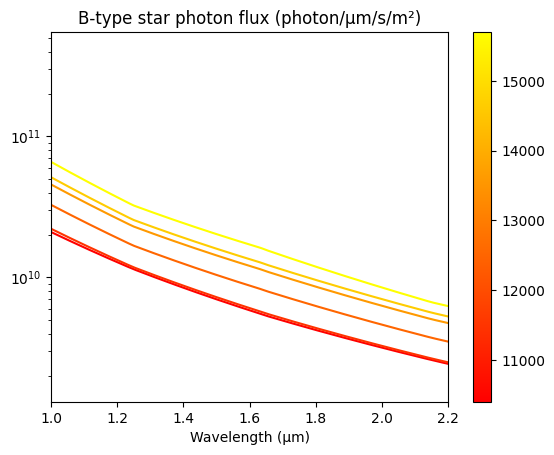

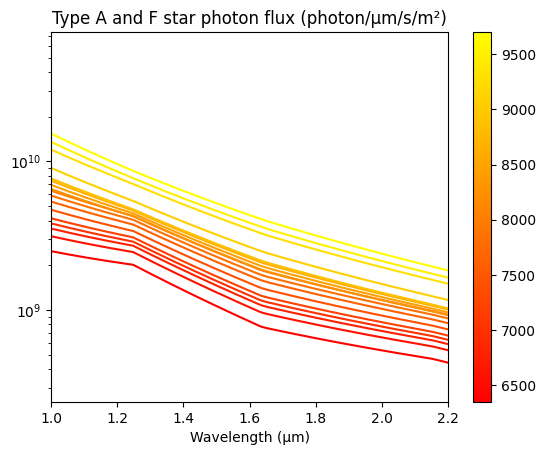

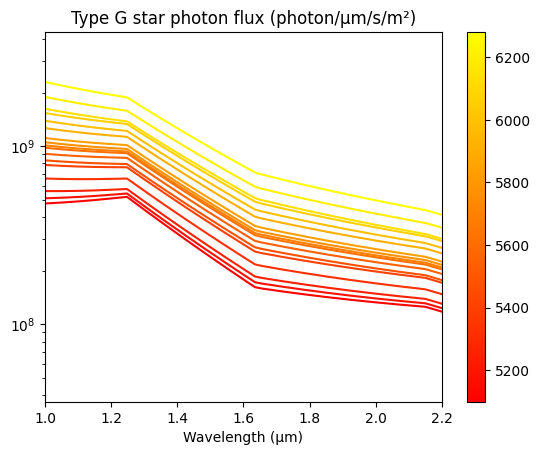

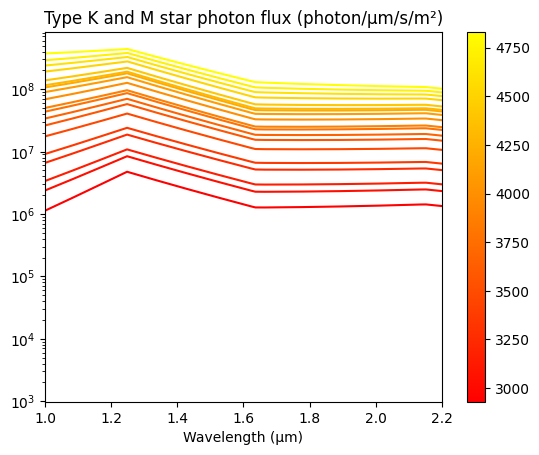

[23310532.64016879 23709297.50815184 24112262.05352518 ...
 72027441.8424793  71948627.1982923  71869918.11728674]


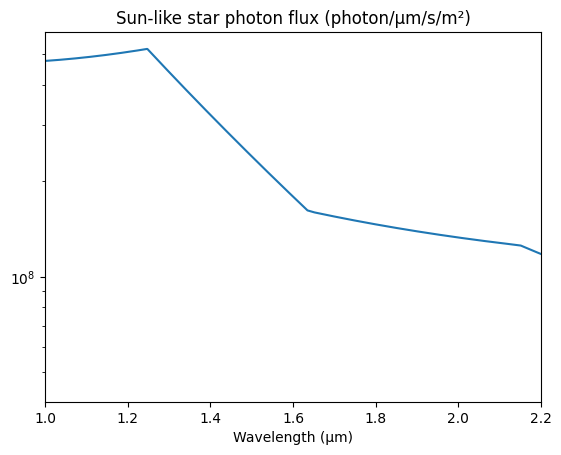

In [11]:
# Star fluxes

# importing the magnitudes for the U, V, J, H, K bands and physical parameters from the file
#data = np.genfromtxt('D:\FROM_RED\PecautMamajek2013_June2025.txt', dtype='str')
data = np.genfromtxt('C:/Users/Red Slottje/Documents/Doc_Rouge/PecautMamajek2013_June2025.txt', dtype='str')

U_B, M_V, M_J, J_H, M_K, B_V =  pd.to_numeric(data[10:90,15], errors='coerce'), pd.to_numeric(data[10:90,7], errors='coerce'), pd.to_numeric(data[10:90,21], errors='coerce'), pd.to_numeric(data[10:90,19], errors='coerce'), pd.to_numeric(data[10:90:,22], errors='coerce'),  pd.to_numeric(data[10:90:,8], errors='coerce')
logL, R_Rsun, masses, t_eff = pd.to_numeric(data[10:90,4], errors='coerce'), pd.to_numeric(data[10:90,6], errors='coerce'), pd.to_numeric(data[10:90,30], errors='coerce'), pd.to_numeric(data[10:90,1], errors='coerce')
M_H = M_J - J_H
M_U = M_V + B_V + U_B

print('List of characterized temperatures : ', t_eff)

# list of the central values of each spectral band (U, V, J, H, K respectively)
# the get_star_spectrum function interpolates between 0.3 and 2.499 microns and needs one value <0.3 and one value >2.499. 
# The 0.299 (U-band) and 2.5 values are there to make sure that the interpolation is done correctly but are irrelevant to our purposes as there are no MICADO filters with these wavelengths.
lbd = [0.299, 0.550, 1.2475 , 1.635, 2.150, 2.500]


############### Plot for B and O stars ################

temp_B_and_O = [15700, 14500, 14000, 12300, 10700 ,10400]

temp_B_and_O.sort()

n = len(temp_B_and_O)
colors = plt.cm.autumn(np.linspace(0,1,n))

c = np.array(temp_B_and_O)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)

# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_B_and_O)):
    for j in range(len(t_eff)):
        if t_eff[j] == temp_B_and_O[i] :
            star_mag = [M_U[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd) 

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])
plt.colorbar(cmap, ax = ax)
plt.title('B-type star photon flux (photon/µm/s/m²)')
plt.xlim(1, 2.2)
plt.yscale('log')
plt.xlabel('Wavelength (µm)')
plt.show()


################ Plot for A and F stars #################

temp_A_and_F = [9700,  9300 , 8800,  8600 , 8250, 8100,  7910 , 7760,
  7590,  7400 , 7220  ,7020 , 6820  ,6750 , 6670 , 6550, 6350]

temp_A_and_F.sort()

n = len(temp_A_and_F)
colors = plt.cm.autumn(np.linspace(0,1,n))

c = np.array(temp_A_and_F)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)

# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_A_and_F)):
    for j in range(len(t_eff)):
        if t_eff[j] == temp_A_and_F[i] :
            star_mag = [M_U[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd) 

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])

plt.colorbar(cmap, ax = ax)
plt.title('Type A and F star photon flux (photon/µm/s/m²)')
plt.xlim(1, 2.2)
plt.yscale('log')
plt.xlabel('Wavelength (µm)')
plt.show()


############### Plot for G type stars ##################

temp_G = [ 6280,  6180,  6050,
  5990,  5930 , 5860  ,5770, 5720 , 5680,  5660,  5600,  5550,  5480,  5380,  5270,
  5170,  5100 ]  

temp_G.sort()

n = len(temp_G)
colors = plt.cm.autumn(np.linspace(0,1,n))

# setting up the colorbar
c = np.array(temp_G)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)
# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_G)):
    
    for j in range(len(t_eff)):
        if t_eff[j] == temp_G[i] :
            star_mag = [M_U[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd) 

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])
plt.colorbar(cmap, ax = ax)
plt.title('Type G star photon flux (photon/µm/s/m²)')
plt.xlim(1, 2.2)
plt.yscale('log')
plt.xlabel('Wavelength (µm)')
plt.show()

################## Plot for the K and M type stars #######################

temp_K_and_M = [4830,  4600,  4440,  4300,  4100,  3990,  3930, 3850,  3770,3660,
  3620,  3560  ,3470  ,3430 , 3270,  3210 , 3110, 3060,  2930]

temp_K_and_M.sort()

n = len(temp_K_and_M)
colors = plt.cm.autumn(np.linspace(0,1,n))

# setting up the colorbar
c = np.array(temp_K_and_M)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)
# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_K_and_M)):
    
    for j in range(len(t_eff)):
        if t_eff[j] == temp_K_and_M[i] :
            star_mag = [M_U[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd)

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])
plt.colorbar(cmap, ax = ax)
plt.title('Type K and M star photon flux (photon/µm/s/m²)')
plt.xlim(1, 2.2)
plt.yscale('log')
plt.xlabel('Wavelength (µm)')
plt.show()


####### Plot for a sun-like star ###############

temp = 5100
for j in range(len(t_eff)):
    if t_eff[j] == temp:
        star_mag = [M_U[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]
wave_tr, star_flux_sol = get_star_spectrum(flux_dir, star_mag, lbd)
print(star_flux)

plt.plot(wave_tr, star_flux_sol)
plt.title('Sun-like star photon flux (photon/µm/s/m²)')
plt.yscale('log')
plt.xlabel('Wavelength (µm)')
plt.xlim(1, 2.2)
plt.show()

In [12]:
################# SETUP FOR THE CONTRAST PLOTS (Define star temperature here) #####################

# extracting the filter data from the input files
tr_filter0  = fits.getdata(flux_dir+'Transmission_filter_J1J2H1H2K1K2_v2020.fits')
tr_filter1  = fits.getdata(flux_dir+'Transmission_filter_JHK.fits')
wave_tr     = fits.getdata(flux_dir+'Wavelength_for_emission_transmission_in_micrometer.fits')
    
wave_step   = np.mean(np.diff(wave_tr))

#defining the bands from the filter 
Jshort = tr_filter0[0,:] #lbd = 1.190
Jlong = tr_filter0[1,:] #lbd = 1.270
Hshort = tr_filter0[2,:] #lbd = 1.582
Hlong = tr_filter0[3,:] #lbd = 1.693
Kmid = tr_filter0[4,:] # lbd = 2.100
K2 = tr_filter0[5,:]  #lbd = 2.220
Jbroad = tr_filter1[0,:] #lbd = 1.245
Hbroad = tr_filter1[1,:] #lbd = 1.635
Kbroad = tr_filter1[2,:] #lbd = 2.145

tr_filter = [Jshort, Jlong, Hshort, Hlong, Kmid, K2]
tr_filter_broad = [Jbroad, Hbroad, Kbroad]

tr_filter_J = [Jshort, Jlong]
tr_filter_H = [Hshort, Hlong]
tr_filter_K = [Kmid, K2]

lbd = [0.299, 0.550, 1.2475, 1.635, 2.150, 2.500]

# pick the star temperature here
temp_star = 2930

star_mag = []
for j in range(len(t_eff)):
    if t_eff[j] == temp_star:
        star_mag = [M_U[j], M_V[j], M_J[j],  M_H[j], M_K[j], M_K[j]]
print('star_mag =', len(star_mag))
print('lbd', lbd)
wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd)
print(star_flux)

star_mag = 6
lbd [0.299, 0.55, 1.2475, 1.635, 2.15, 2.5]
[  1820.9634514    1862.15870698   1904.07887355 ... 949506.60569828
 948467.62634032 947430.0385761 ]


In [13]:
def get_contrast_from_contrast_curve_file(fits_path, distance_in_mas):
    """
    By Trisan Deseine (June 2026)
    Get the contrast value from a contrast curve FITS file at a given distance in milliarcseconds (mas).
    
    Parameters:
    - fits_path: str or Path, path to the FITS file containing the contrast curve.
    - distance_in_mas: float, the distance in milliarcseconds for which to retrieve the contrast.
    
    Returns:
    - contrast_value: float, the contrast value at the specified distance. Returns None if the distance is out of bounds.
    """
    
    # Open the FITS file and read the data
    with fits.open(fits_path) as hdul:
        data = hdul[1].data  # Assuming the contrast curve is in the first extension
    
    # Extract separation and contrast values
    separations = data['separation_mas']
    contrasts = data['contrast_5sigma']
    
    # Find the index of the closest separation value
    idx = (np.abs(separations - distance_in_mas)).argmin()
    
    # Check if the closest separation is within a reasonable range 
    if np.abs(separations[idx] - distance_in_mas) <= 1.0:
        return contrasts[idx]
    else:
        return None  # Return None if the distance is out of bounds
    
lbd = [1.19, 1.245, 1.27, 1.582, 1.635, 1.693, 2.1, 2.145, 2.235]
band = ['J', 'J', 'J', 'H', 'H', 'H', 'K', 'K', 'K']
dist_in_mas = np.array([50, 100, 200, 400])
mic_sens = []
for i in range(len(dist_in_mas)):
    #for j in range(len(lbd)):
    mic_sens.append([get_contrast_from_contrast_curve_file(f'D:/FROM_RED/resampled_by_tristan/No_Planet/CLC15/NoNCPA/Q1/filter{lbd[j]}/Samp1.5/No_Planet_CLC15_NoNCPA_Q1_{band[j]}{lbd[j]}_m_samp1.5_no_noise_contrast_curve.fits',dist_in_mas[i]) for j in range(len(lbd))])
    #print('lbd =', lbd[j])
    print('dist_in_mas =', dist_in_mas[i])
    print(f'micado sensitivity for dist_mas = {dist_in_mas[i]} :', mic_sens[i])

dist_in_mas = 50
micado sensitivity for dist_mas = 50 : [np.float64(4.097860984705257e-06), np.float64(3.994232832131136e-06), np.float64(3.9004729312607145e-06), np.float64(3.004888458923688e-06), np.float64(3.6269611580245543e-06), np.float64(3.453352489860344e-06), np.float64(2.2564832530404755e-06), np.float64(2.6585778726859925e-06), np.float64(2.508495572671452e-06)]
dist_in_mas = 100
micado sensitivity for dist_mas = 100 : [np.float64(1.505641000624955e-06), np.float64(1.1855698729307568e-06), np.float64(1.662103120603484e-06), np.float64(1.4751787741907602e-06), np.float64(1.2731191471109925e-06), np.float64(1.4589990392818059e-06), np.float64(9.985406967580493e-07), np.float64(9.65889640950648e-07), np.float64(1.1283818116060977e-06)]
dist_in_mas = 200
micado sensitivity for dist_mas = 200 : [np.float64(5.732647475738057e-07), np.float64(4.002030905367601e-07), np.float64(4.993820000254374e-07), np.float64(5.131616021203091e-07), np.float64(4.1257283339224386e-07), np.float64(

1.183


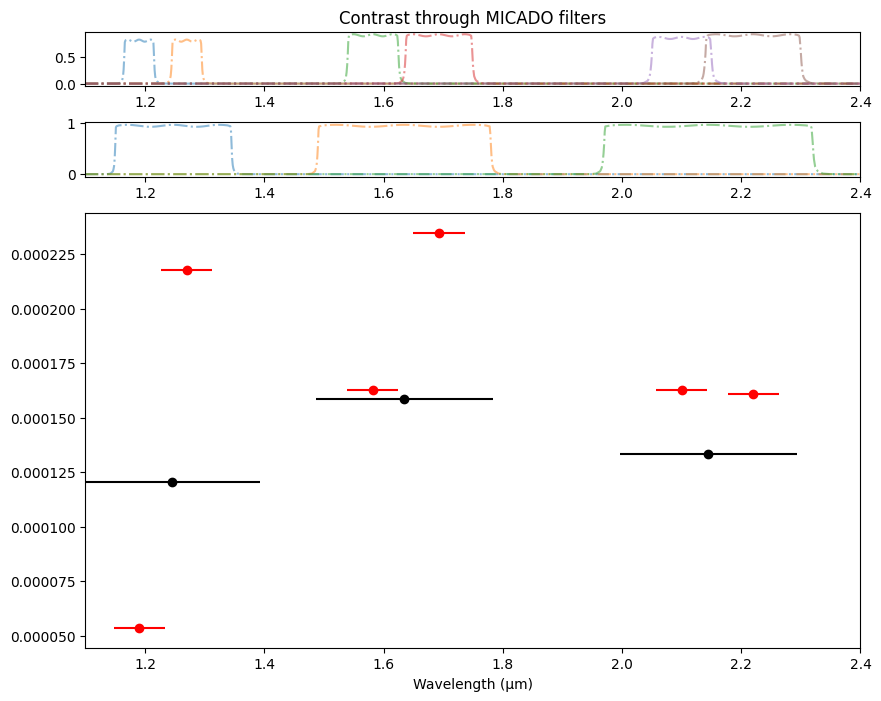

In [14]:
# contrast 

# planet parameters
metallicity = 3.16
CO = 0.15
temp = 800
logg = 3.5

lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]

lbd_broadband =  [1.245 , 1.635, 2.145]

lbd_midband =   [1.190, 1.270, 1.582, 1.693, 2.100, 2.220]

# initiating the storage lists
contrast_broad = []
contrast_mid = []


# calculating the delta of the filters 
new_tr_filter_J = []
new_tr_filter_H = []
new_tr_filter_K = []
new_tr_filter_broad = []

new_tr_filter = []

for i in range(len(tr_filter)):
    for j in range(len(tr_filter[i])) :
        if tr_filter[i][j] >0.05 :
            new_tr_filter.append(wave_tr[j])


for i in range(len(tr_filter_K)):
    new_tr_filter_K = [wave_tr[j] for j in range(len(wave_tr)) if tr_filter[i][j] > 0.05]

for i in range(len(tr_filter_J)):
    for j in range(len(tr_filter_J[i])) :
        if tr_filter_J[i][j] >0.05 :
            new_tr_filter_J.append(wave_tr[j])


for i in range(len(tr_filter_broad)):
    for j in range(len(tr_filter_broad[i])) :
        if tr_filter_broad[i][j] >0.05 :
            new_tr_filter_broad.append(wave_tr[j])

width_tr_filter_broad = max(new_tr_filter_broad) - min(new_tr_filter_broad)
width_tr_filter_K = max(new_tr_filter_K) - min(new_tr_filter_K)
width_tr_filter_J = max(new_tr_filter_J) - min(new_tr_filter_J)
width_tr_filter = max(new_tr_filter) - min(new_tr_filter)

print(width_tr_filter_broad)


# calculating the spectrum of the planet whose caracteristics were outlined in the parameteres section
planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)

# get flux of the correct wavelengths for both star and planet, then calculating the contrast for each wavelength        
for i in range(len(lbd_broadband)):

    photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)

    planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
    contrast_broad.append(planet_photon_flux/photon_flux)

for i in range(len(lbd_midband)):

    photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)

    planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
    contrast_mid.append(planet_photon_flux/photon_flux)

fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))

#plot the filters
for i in range(len(tr_filter)):
    axs[0].set_title('Contrast through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.10, 2.40)

for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.10, 2.40)



# plot the contrast through the filters
"""have to add the different sized errorbars for the different narrow filters"""
axs[2].errorbar(lbd_broadband, contrast_broad, xerr = (width_tr_filter_broad)/8,fmt = 'o', color = 'k', ecolor = 'k')
axs[2].errorbar(lbd_midband, contrast_mid, xerr = (width_tr_filter_J*5)/16, fmt = 'o', color = 'r', ecolor = 'r')
axs[2].set_xlim(1.10, 2.40)
plt.xlabel('Wavelength (µm)')
plt.show()


In [15]:
hdul = fits.open("physical_planet_parameters_storage.fits")
hdu = hdul[1]
metallicity = hdu.data
temp = hdul[2].data
print(metallicity)


[(  0.32,) (  1.  ,) (  3.16,) ( 10.  ,) ( 31.62,) (100.  ,)]


[np.float64(4.097860984705257e-06), np.float64(3.994232832131136e-06), np.float64(3.9004729312607145e-06), np.float64(3.004888458923688e-06), np.float64(3.6269611580245543e-06), np.float64(3.453352489860344e-06), np.float64(2.2564832530404755e-06), np.float64(2.6585778726859925e-06), np.float64(2.508495572671452e-06)]
[np.float64(1.505641000624955e-06), np.float64(1.1855698729307568e-06), np.float64(1.662103120603484e-06), np.float64(1.4751787741907602e-06), np.float64(1.2731191471109925e-06), np.float64(1.4589990392818059e-06), np.float64(9.985406967580493e-07), np.float64(9.65889640950648e-07), np.float64(1.1283818116060977e-06)]
[np.float64(5.732647475738057e-07), np.float64(4.002030905367601e-07), np.float64(4.993820000254374e-07), np.float64(5.131616021203091e-07), np.float64(4.1257283339224386e-07), np.float64(5.271337489888353e-07), np.float64(4.473067455015784e-07), np.float64(3.5211200839788645e-07), np.float64(4.255297198125237e-07)]
[np.float64(9.254425797764288e-07), np.flo

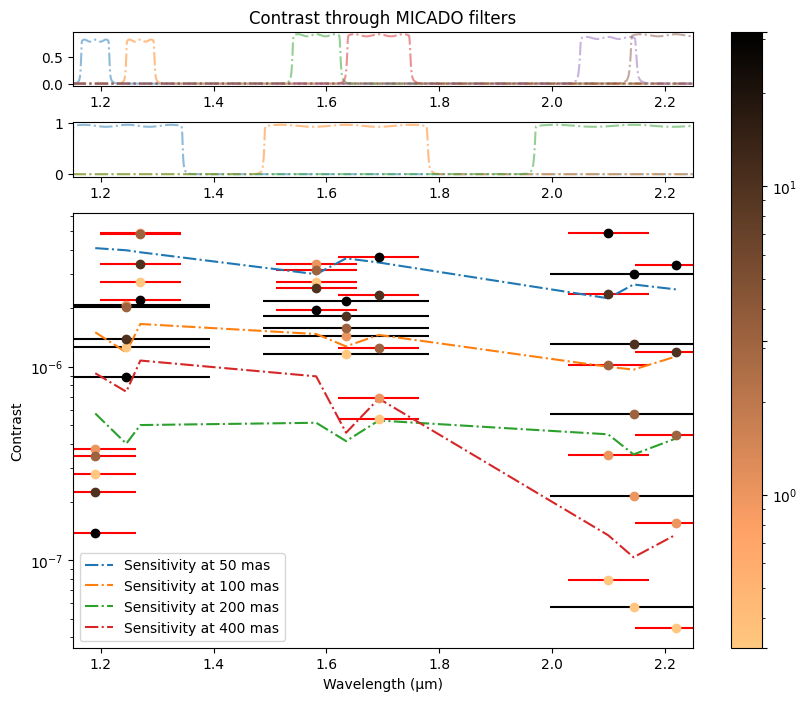

In [16]:
# contrast iterating on metallicity
#metallicity = 3.16
CO = 0.10
#temp = np.arange(200,2000,100)
temp = 400
logg = 3.0
#lbd = [1.2475 , 1.635, 2.145]

lbd_broadband =  [1.245 , 1.635, 2.145]

lbd_midband =   [1.190, 1.270, 1.582, 1.693, 2.100, 2.220]
#lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62]#, 100.00]

photon_flux_midband = []
photon_flux_broadband = []
planet_photon_flux_list = []

#setting up the color coding of the plots
n = len(metallicity)
colors = plt.cm.copper_r(np.linspace(0,1,n))

# initiating the figure
fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))

# setting up the colorbar
c = np.array(metallicity)
norm = mpl.colors.LogNorm(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.copper_r)
cmap.set_array([])

# calculating the star fluxes in separate lists for broadband and midband
for i in range(len(lbd_midband)):
        photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        photon_flux_midband.append(photon_flux)

for i in range(len(lbd_broadband)):
        photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        photon_flux_broadband.append(photon_flux)

# for each metallicity in the list, get the planet spectrum and the contrast in each band 
for k in range(len(metallicity)) :
    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity[k], CO, dist_pc, r_pl, flux_dir=flux_dir)

    contrast_mid = []
    contrast_broad = []

    for i in range(len(lbd_midband)):
    
        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_mid.append(planet_photon_flux/photon_flux_midband[i])
    axs[2].errorbar(lbd_midband, contrast_mid, xerr = (width_tr_filter)/16, fmt = 'o', color = colors[k], ecolor = 'r')


    for i in range(len(lbd_broadband)):

        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        contrast_broad.append(planet_photon_flux/photon_flux_broadband[i])
    axs[2].errorbar(lbd_broadband, contrast_broad, xerr = (width_tr_filter_broad)/8,fmt = 'o', color = colors[k], ecolor = 'k')
# width_tr_filter and width_tr_filter_broad are defined in the previous cell

for i in range(len(tr_filter)):
    axs[0].set_title('Contrast through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.150, 2.250)

for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.150, 2.250)

lbd.sort()
for i in range(len(mic_sens)):
    print(mic_sens[i])
    axs[2].plot(lbd, mic_sens[i], '-.', label = f'Sensitivity at {dist_in_mas[i]} mas')

axs[2].set_xlim(1.150, 2.250)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Contrast')
plt.yscale('log')
plt.colorbar(cmap, ax = axs, ticks = metallicity)
plt.legend()
plt.savefig('D:/FROM_RED/flux_and_contrasts/'+ f'Contrast_on_met_logg{logg}_CO _{CO}_temp_{temp}.png')
plt.show()

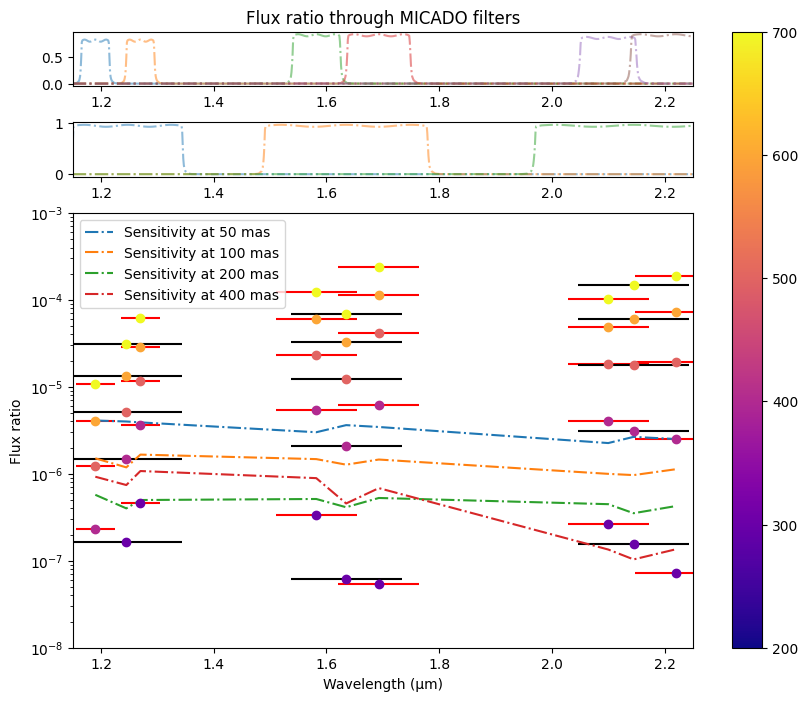

In [17]:
# contrast iterating on temp WITH Micado sensitivity
metallicity = 31.62
CO =  0.15 # [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
temp = np.arange(200,800,100)
logg = 3.5
#lbd = [1.2475 , 1.635, 2.145]
lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]
lbd_midband =   [1.582, 1.693, 2.100, 2.220]
#metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]

n = len(temp)
colors = plt.cm.plasma(np.linspace(0,1,n))

photon_flux_list = []
planet_photon_flux_list = []
contrast_mid = []
contrast_broad = []
new_filter_J = []

# for i in range(len(tr_filter)):
#     if tr_filter[i] > 0.0005:
#         new_filter.append(tr_filter[i])

for i in range(len(tr_filter_J)):
    new_filter_J = [wave_tr[j] for j in range(len(wave_tr)) if tr_filter_J[i][j] > 0.05]

fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))
c = np.array(temp)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.plasma)
cmap.set_array([])

##### THE FOLLOWING COMMENTED SECTION HAS HAS ALREADY BEEN DONE IN THE PREVIOUS CELL ########

# # calculating the star fluxes in separate lists for broadband and midband
# for i in range(len(lbd_midband)):
#         photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
#                                                                     star_flux, f'{lbd_midband[i]:5.3f}', 
#                                                                     frame_exp_time, telescope_surface, 
#                                                                     airmass=airmass, pixel_scale=pixscale_in_mas)
#         photon_flux_midband.append(photon_flux)

# for i in range(len(lbd_broadband)):
#         photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
#                                                                     star_flux, f'{lbd_broadband[i]:5.3f}', 
#                                                                     frame_exp_time, telescope_surface, 
#                                                                     airmass=airmass, pixel_scale=pixscale_in_mas)
#         photon_flux_broadband.append(photon_flux)

#################################################################################################

lbd_Jband = [1.190, 1.270]
photon_flux_Jband = []

for i in range(len(lbd_Jband)):
        photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_Jband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        photon_flux_Jband.append(photon_flux)

# calculating the contrast with planets of different temperatures
for k in range(len(temp)) :
    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)

    contrast_mid = []
    contrast_broad = []
    contrast_J = []

    for i in range(len(lbd_Jband)) :
        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_Jband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_J.append(planet_photon_flux/photon_flux_Jband[i])
        
    for i in range(len(lbd_midband)):
    
        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_mid.append(planet_photon_flux/photon_flux_midband[i])
    axs[2].errorbar(lbd_midband, contrast_mid, xerr = (width_tr_filter)/16, fmt = 'o', color = colors[k], ecolor = 'r')
    axs[2].errorbar(lbd_Jband, contrast_J, xerr = (width_tr_filter_J)/4, fmt = 'o', color = colors[k], ecolor = 'r')

    for i in range(len(lbd_broadband)):

        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        contrast_broad.append(planet_photon_flux/photon_flux_broadband[i])
    axs[2].errorbar(lbd_broadband, contrast_broad, xerr = (width_tr_filter_broad)/12,fmt = 'o', color = colors[k], ecolor = 'k')


for i in range(len(tr_filter)):
    axs[0].set_title('Flux ratio through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.150, 2.250)

for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.150, 2.250)


#mic_sens[3].sort()
lbd.sort()
for i in range(len(mic_sens)):
    axs[2].plot(lbd, mic_sens[i], '-.', label = f'Sensitivity at {dist_in_mas[i]} mas')

axs[2].set_xlim(1.150, 2.250)
plt.legend()
plt.ylim(10**-8, 10**-3)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux ratio')
plt.yscale('log')
plt.colorbar(cmap, ax = axs, ticks = temp)
plt.savefig(f'D:/FROM_RED/flux_and_contrasts/UPDATED/'+ f'Contrast by temp_CO{CO}_met{metallicity}_logg{logg}_10-14.png')
plt.show()



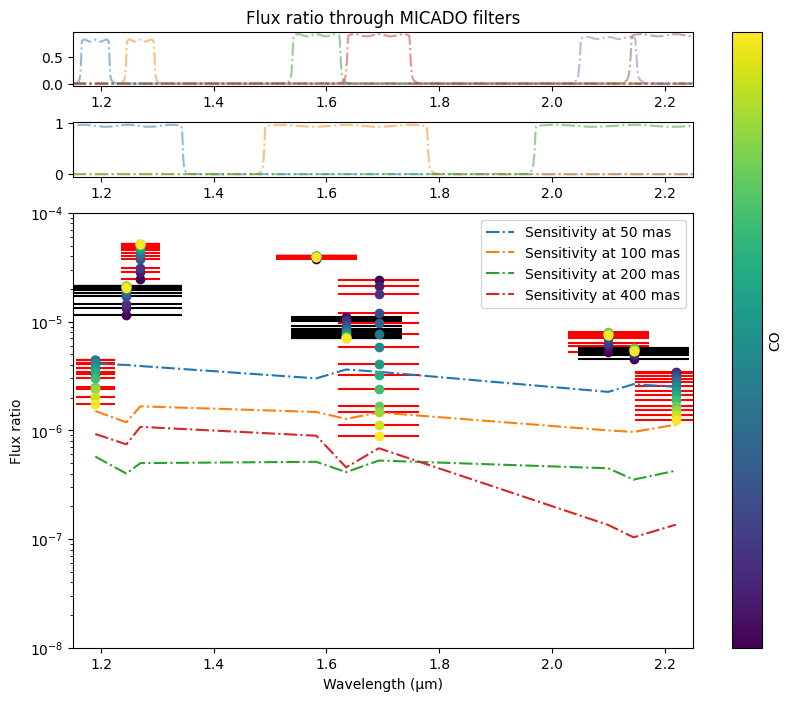

In [37]:
# contrast iterating on CO WITH Micado sensitivity
metallicity = 3.16
CO = np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80])
temp = 500 #np.arange(200,1000,100)
logg = 3.5
#lbd = [1.2475 , 1.635, 2.145]
lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]
lbd_midband =   [1.582, 1.693, 2.100, 2.220]
#metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]

n = len(CO)
colors = plt.cm.viridis(np.linspace(0,1,n))

photon_flux_list = []
planet_photon_flux_list = []
contrast_mid = []
contrast_broad = []
new_filter_J = []

# for i in range(len(tr_filter)):
#     if tr_filter[i] > 0.0005:
#         new_filter.append(tr_filter[i])

for i in range(len(tr_filter_J)):
    new_filter_J = [wave_tr[j] for j in range(len(wave_tr)) if tr_filter_J[i][j] > 0.05]

fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))
c = np.array(temp)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

##### THE FOLLOWING COMMENTED SECTION HAS HAS ALREADY BEEN DONE IN THE PREVIOUS CELL ########

# # calculating the star fluxes in separate lists for broadband and midband
# for i in range(len(lbd_midband)):
#         photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
#                                                                     star_flux, f'{lbd_midband[i]:5.3f}', 
#                                                                     frame_exp_time, telescope_surface, 
#                                                                     airmass=airmass, pixel_scale=pixscale_in_mas)
#         photon_flux_midband.append(photon_flux)

# for i in range(len(lbd_broadband)):
#         photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
#                                                                     star_flux, f'{lbd_broadband[i]:5.3f}', 
#                                                                     frame_exp_time, telescope_surface, 
#                                                                     airmass=airmass, pixel_scale=pixscale_in_mas)
#         photon_flux_broadband.append(photon_flux)

#################################################################################################

lbd_Jband = [1.190, 1.270]
photon_flux_Jband = []

for i in range(len(lbd_Jband)):
        photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_Jband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        photon_flux_Jband.append(photon_flux)

# calculating the contrast with planets of different temperatures
for k in range(len(CO)) :
    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity, CO[k], dist_pc, r_pl, flux_dir=flux_dir)

    contrast_mid = []
    contrast_broad = []
    contrast_J = []

    for i in range(len(lbd_Jband)) :
        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_Jband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_J.append(planet_photon_flux/photon_flux_Jband[i])
        
    for i in range(len(lbd_midband)):
    
        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_mid.append(planet_photon_flux/photon_flux_midband[i])
    axs[2].errorbar(lbd_midband, contrast_mid, xerr = (width_tr_filter)/16, fmt = 'o', color = colors[k], ecolor = 'r')
    axs[2].errorbar(lbd_Jband, contrast_J, xerr = (width_tr_filter_J)/4, fmt = 'o', color = colors[k], ecolor = 'r')

    for i in range(len(lbd_broadband)):

        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        contrast_broad.append(planet_photon_flux/photon_flux_broadband[i])
    axs[2].errorbar(lbd_broadband, contrast_broad, xerr = (width_tr_filter_broad)/12,fmt = 'o', color = colors[k], ecolor = 'k')


for i in range(len(tr_filter)):
    axs[0].set_title('Flux ratio through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.150, 2.250)

for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.150, 2.250)


#mic_sens[3].sort()
lbd.sort()
for i in range(len(mic_sens)):
    axs[2].plot(lbd, mic_sens[i], '-.', label = f'Sensitivity at {dist_in_mas[i]} mas')

axs[2].set_xlim(1.150, 2.250)
plt.legend()
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux ratio')
plt.yscale('log')
plt.ylim(10**-8, 10**-4)
plt.colorbar(cmap, ax = axs, ticks = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80], label = 'CO')
plt.savefig(f'D:/FROM_RED/flux_and_contrasts/UPDATED/CO/'+ f'Contrast by CO_temp{temp}_met{metallicity}_logg{logg}.png')
plt.show()


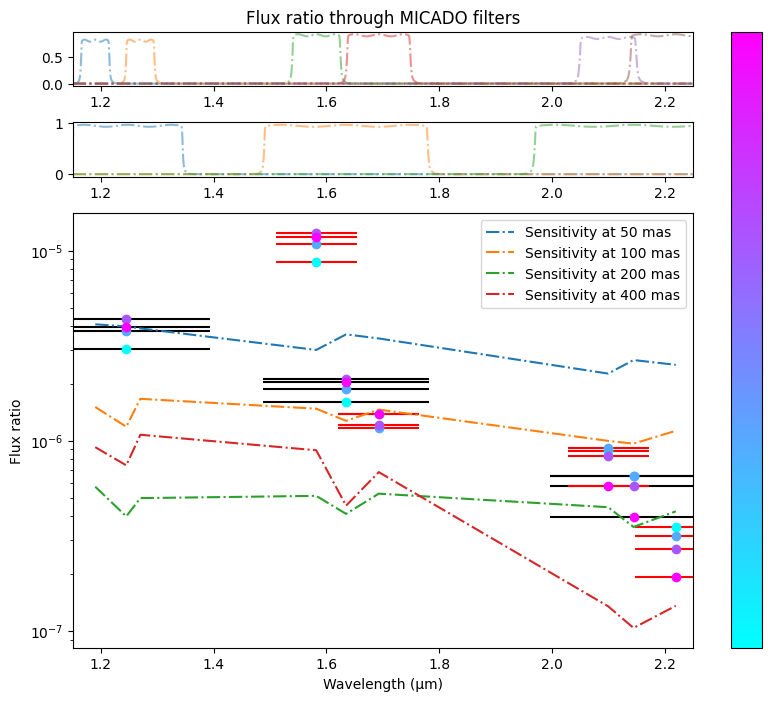

In [19]:
# contrast iterating on logg WITH Micado sensitivity
metallicity = 3.16
CO = 0.15
temp = 400
logg = [3.5, 4.0, 4.5, 5.0]
#lbd = [1.2475 , 1.635, 2.145]
lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]
#metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
lbd_midband =   [1.582, 1.693, 2.100, 2.220]

n = len(logg)
colors = plt.cm.cool(np.linspace(0,1,n))

photon_flux_list = []
planet_photon_flux_list = []
contrast_mid = []
contrast_broad = []

# for i in range(len(tr_filter)):
#     if tr_filter[i] > 0.0005:
#         new_filter.append(tr_filter[i])

# for j in range(len(tr_filter_broad)):
#     if tr_filter_broad[i] > 0.0005:
#         new_filter_broad.append(tr_filter_broad[i])

fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))
c = np.array(temp)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cool)
cmap.set_array([])

##### THE FOLLOWING COMMENTED SECTION HAS HAS ALREADY BEEN DONE IN THE PREVIOUS CELL ########

# # calculating the star fluxes in separate lists for broadband and midband
# for i in range(len(lbd_midband)):
#         photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
#                                                                     star_flux, f'{lbd_midband[i]:5.3f}', 
#                                                                     frame_exp_time, telescope_surface, 
#                                                                     airmass=airmass, pixel_scale=pixscale_in_mas)
#         photon_flux_midband.append(photon_flux)

# for i in range(len(lbd_broadband)):
#         photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
#                                                                     star_flux, f'{lbd_broadband[i]:5.3f}', 
#                                                                     frame_exp_time, telescope_surface, 
#                                                                     airmass=airmass, pixel_scale=pixscale_in_mas)
#         photon_flux_broadband.append(photon_flux)

#################################################################################################

# calculating the contrast with planets of different temperatures
for k in range(len(logg)) :
    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg[k], metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)

    contrast_mid = []
    contrast_broad = []

    for i in range(len(lbd_midband)):
    
        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_mid.append(planet_photon_flux/photon_flux_midband[i])
    axs[2].errorbar(lbd_midband, contrast_mid, xerr = (width_tr_filter)/16, fmt = 'o', color = colors[k], ecolor = 'r')


    for i in range(len(lbd_broadband)):

        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_broadband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        contrast_broad.append(planet_photon_flux/photon_flux_broadband[i])
    axs[2].errorbar(lbd_broadband, contrast_broad, xerr = (width_tr_filter_broad)/8,fmt = 'o', color = colors[k], ecolor = 'k')


for i in range(len(tr_filter)):
    axs[0].set_title('Flux ratio through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.150, 2.250)

for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.150, 2.250)


#mic_sens[3].sort()
lbd.sort()
for i in range(len(mic_sens)):
    axs[2].plot(lbd, mic_sens[i], '-.', label = f'Sensitivity at {dist_in_mas[i]} mas')

axs[2].set_xlim(1.150, 2.250)
plt.legend()
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux ratio')
plt.yscale('log')
plt.colorbar(cmap, ax = axs, ticks = logg)
plt.savefig('D:/FROM_RED/flux_and_contrasts/'+ f'Contrast by logg_temp{temp}_CO{CO}_met{metallicity}.png')
plt.show()


In [20]:
####### Probably useless #####

lbd_broadband =  [1.245 , 1.635, 2.145]

lbd_midband =   [1.190, 1.270, 1.582, 1.693, 2.100]

for i in range(len(lbd_midband)):

        photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        
        planet_photon_flux_mid, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_midband[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas) 
        contrast_mid = planet_photon_flux_mid/photon_flux
        for j in range(len(lbd_broadband)):

                photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_broadband[j]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
                
                planet_photon_flux_broad, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd_broadband[j]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
                
                contrast_broad = planet_photon_flux_broad/photon_flux
                contrast = contrast_mid/contrast_broad
 


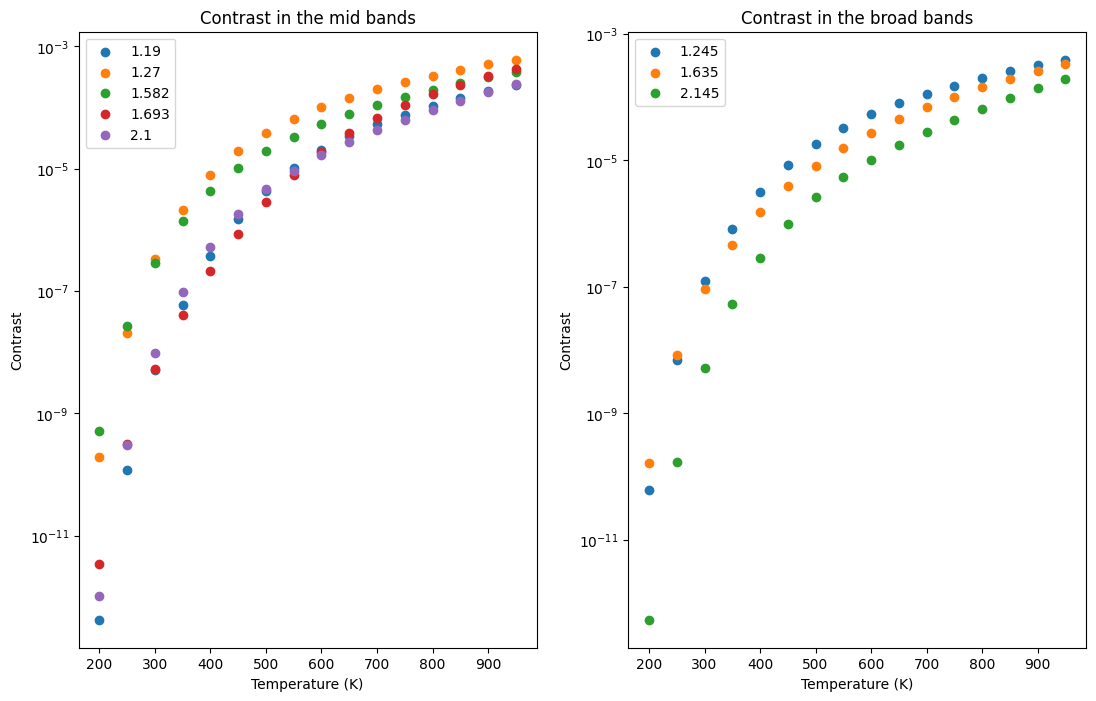

In [21]:
# Y-contrast vs X-temperature

lbd_broadband = [1.245 , 1.635, 2.145]
lbd_midband = [1.190, 1.270, 1.582, 1.693, 2.100]

metallicity = 1.0
temp = np.arange(200, 1000, 50)
logg = 3.5
#CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
CO = 0.30


fig, ax = plt.subplots(1,2, figsize = (13,8))

for j in range(len(lbd_midband)):
    total_flux = []
    for k in range(len(temp)) :
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)

        photon_flux_mid, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_midband[j]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)

        planet_photon_flux_mid, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                        planet_flux, f'{lbd_midband[j]:5.3f}', 
                                                                        frame_exp_time, telescope_surface, 
                                                                        airmass=airmass, pixel_scale=pixscale_in_mas)
        total_flux.append((planet_photon_flux_mid/photon_flux_mid))
    
    ax[0].scatter(temp, total_flux)


for j in range(len(lbd_broadband)):
    total_flux = []
    for k in range(len(temp)) :
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)

        photon_flux_broad, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd_broadband[j]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)

        planet_photon_flux_broad, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                        planet_flux, f'{lbd_broadband[j]:5.3f}', 
                                                                        frame_exp_time, telescope_surface, 
                                                                        airmass=airmass, pixel_scale=pixscale_in_mas)
        total_flux.append((planet_photon_flux_broad/photon_flux_broad))
    
    ax[1].scatter(temp, total_flux)

ax[0].set_yscale('log')
ax[0].set_title('Contrast in the mid bands')
ax[0].set_xlabel('Temperature (K)')
ax[0].set_ylabel('Contrast')
ax[0].legend([1.190, 1.270, 1.582, 1.693, 2.100])

ax[1].set_yscale('log')
ax[1].set_title('Contrast in the broad bands')
ax[1].set_xlabel('Temperature (K)')
ax[1].set_ylabel('Contrast')
ax[1].legend([1.245 , 1.635, 2.145])
plt.show()


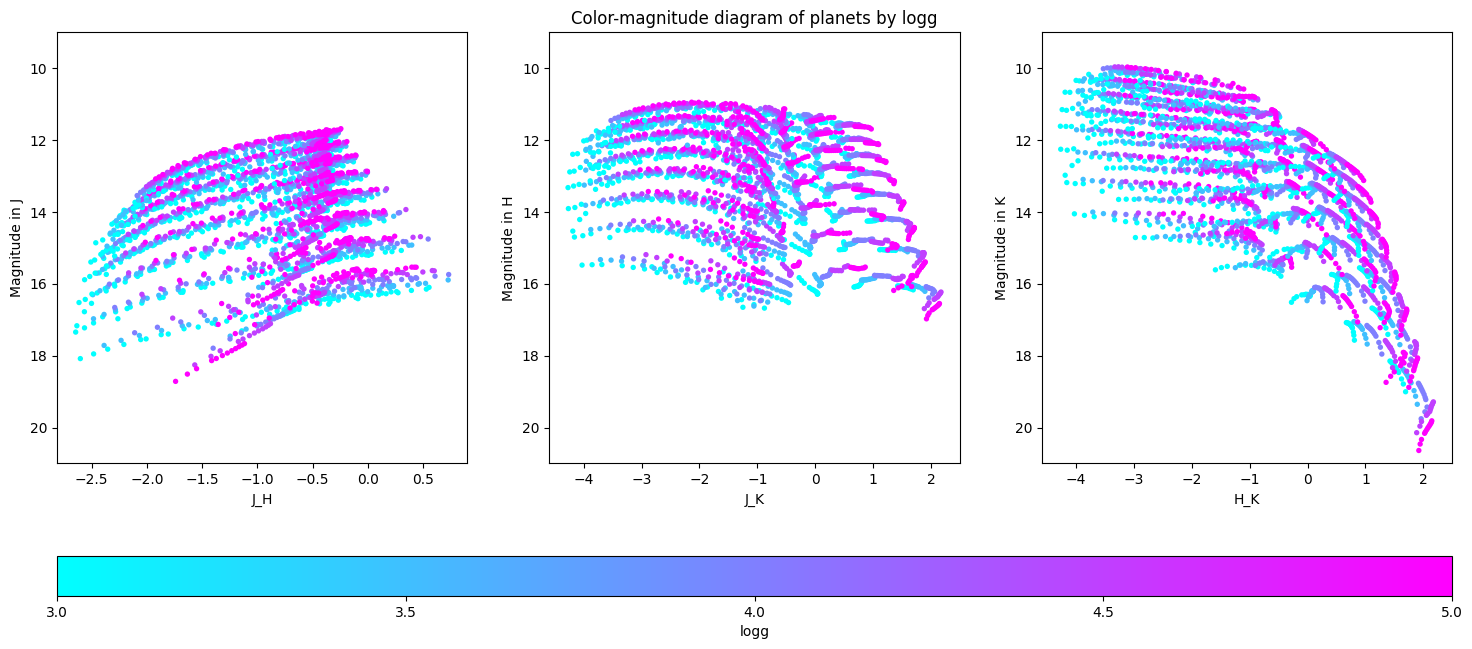

In [22]:
# Color - magnitude plots J, H, K
#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig, ax = plt.subplots(1, 3, figsize=(18, 8), sharey=False)


spec_dir = 'C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/'
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
#met = 0.32
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
#logg = 3.5
#CO = 0.45

CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
temp = np.arange(400, 800, 50)
r_pl    = 1
dist_pc = 39.4



# metallicity = np.array([0.32, 1.00, 3.16, 10.00, 31.62, 100.00])
# temp = np.arange(200, 1000, 50)
# logg = np.array([3.0, 3.5, 4.0, 4.5, 5.0])
# CO =  np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70])
# lbd = np.array([1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145])
# U_B, M_V, M_J, J_H, M_K, B_V =  pd.to_numeric(data[10:90,15], errors='coerce'), pd.to_numeric(data[10:90,7], errors='coerce'), pd.to_numeric(data[10:90,21], errors='coerce'), pd.to_numeric(data[10:90,19], errors='coerce'), pd.to_numeric(data[10:90:,22], errors='coerce'),  pd.to_numeric(data[10:90:,8], errors='coerce')
# logL, R_Rsun, masses, t_eff = pd.to_numeric(data[10:90,4], errors='coerce'), pd.to_numeric(data[10:90,6], errors='coerce'), pd.to_numeric(data[10:90,30], errors='coerce'), pd.to_numeric(data[10:90,1], errors='coerce')
# M_H = M_J - J_H
# M_U = M_V + B_V + U_B
# J_K = M_J - M_K
# H_K = M_H -M_K

color_code = logg

n = len(color_code)

#if color_code == temp.all() :
# colors = plt.cm.plasma(np.linspace(0,1,n))
# c = np.array(color_code)
# norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
# cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.plasma)
# cmap.set_array([])
# idx = i

# if color_code == CO :
# colors = plt.cm.viridis(np.linspace(0,1,n))
# c = np.array(color_code)
# norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
# cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
# cmap.set_array([])
# idx = l

# if color_code == logg :
colors = plt.cm.cool(np.linspace(0,1,n))
c = np.array(color_code)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cool)
cmap.set_array([])
idx = j

# if color_code == metallicity:
#     colors = plt.cm.copper_r(np.linspace(0,1,n))
#     norm = mpl.colors.LogNorm(vmin=c.min(), vmax=c.max())
#     cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.copper_r)
#     cmap.set_array([])
#     idx = k
#need to index flux_zero to get the correct flux wavelengths
planet_mag_J = []
planet_mag_H = []
planet_mag_K = []
lbd_midband = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220]
lbd_broadband =  [1.245 , 1.635, 2.145]


flux_zero   = fits.getdata(flux_dir+'Zero_mag_in_phot_per_m2_per_um_per_s.fits')

#print(flux_zero)
#planet_mag_broad_list = []
for i in range(len(temp)) :
    for j in range(len(logg)):
        for k in range(len(metallicity)):
            for l in range(len(CO)):
                #print ('indexes :', i, j, k, l)
                #print('temp = ', temp[i], 'logg = ', logg[j], 'met = ', metallicity[k], 'CO =', CO[l])
                if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg[j]}_met{metallicity[k]}_CO{CO[l]}.dat' != 0:
                    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, 
                                                flux_dir=flux_dir) # if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg}_met{metallicity}_CO{CO}.dat' != 0]

                else : 
                    continue
                
                planet_mag_J = []
                planet_mag_H = []
                planet_mag_K = []
                flux_ref =[]

                for n in range(len(lbd_broadband)):
                    if lbd_broadband[n] == 1.245 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_broadband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.245]
                        #print('flux ref J =', flux_ref)
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0])
                        #print('flux ratio J =', flux_ratio)                      
                        planet_mag_J.append(-2.5*math.log(flux_ratio, 10))# if i != 0]
                        #planet_mag_J.append(-2.5*math.log(planet_photon_flux))

                    if lbd_broadband[n] == 1.635 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_broadband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.635]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0])                
                        #print('flux ref H =', flux_ref)
                        #print('flux ratio H =', flux_ratio)
                        planet_mag_H.append(-2.5*math.log(flux_ratio, 10))
                        # planet_mag_H = [-2.5*math.log(planet_photon_flux/flux_ref)]# if i != 0]

                    if lbd_broadband[n] == 2.145 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_broadband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0]) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_K.append(-2.5*math.log(flux_ratio, 10))
                        # planet_mag_K = [-2.5*math.log(planet_photon_flux/flux_ref)]# if i != 0]
                        
                        #planet_mag_K.append(-2.5*math.log(planet_photon_flux))   

                J_H = -(np.array(planet_mag_J) - np.array(planet_mag_H))
                J_K = -(np.array(planet_mag_J) - np.array(planet_mag_K))
                H_K = -(np.array(planet_mag_H) - np.array(planet_mag_K))
                

                ax[0].scatter(J_H, planet_mag_J, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[0].set_xlabel('J_H')
                ax[0].set_ylabel('Magnitude in J')
                ax[0].set_ylim(21,9)
                ax[1].scatter(J_K, planet_mag_H, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[1].set_xlabel('J_K')
                ax[1].set_ylabel('Magnitude in H')
                ax[1].set_ylim(21,9)
                ax[2].scatter(J_K, planet_mag_K, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[2].set_xlabel('H_K')
                ax[2].set_ylabel('Magnitude in K')
                ax[2].set_ylim(21,9)
ax[1].set_title('Color-magnitude diagram of planets by logg')
plt.colorbar(cmap, ax = ax, location = 'bottom', orientation = 'horizontal', aspect = 35, label = 'logg', ticks = color_code)
plt.savefig('D:/FROM_RED/flux_and_contrasts/'+ f'Color coded by logg UPDATED')
plt.show()

In [23]:
#contrast_broad.append(planet_photon_flux/photon_flux_broadband[i])
                #axs[2].errorbar(lbd_broadband, contrast_broad, xerr = (width_tr_filter_broad)/8,fmt = 'o', color = colors[k], ecolor = colors[k])

                #planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, flux_dir=flux_dir)
                
'''                planet_mag = [-2.5*math.log(planet_flux[i]/flux_zero[j]) for i in range(len(planet_flux)) if planet_flux[i] != 0]
                print('planet_mag' , len(planet_mag))
                bande_J = [x for x in spec_wave if x > 1.150 and x < 1.345]
                bande_H = [x for x in spec_wave if x > 1.490 and x < 1.780]
                bande_K = [x for x in spec_wave if x > 1.970 and x < 2.330]
                M_J = []
                M_H = []
                M_K = []
                J_H = []
                J_K = []
                H_K = []
                print('bande_J' ,bande_J)
                for m in range(len(spec_wave)):
                    if spec_wave[m] in bande_J :
                        M_J.append(planet_mag[m])
                    if spec_wave[m] in bande_H :
                        M_H.append(planet_mag[m])
                    if spec_wave[m] in bande_K :
                        M_K.append(planet_mag[m])
                for n in range(len(M_J)):
                    J_H.append(M_J[n] - M_H[n])
                    J_K.append(M_J[n] - M_K[n])
                for p in range(len(M_H)):
                    H_K.append(M_H[p] - M_K[p])
                #print('M_H =',len(M_H))
                print(len(J_H), len(M_J))
                print(len(J_K), len(M_H))
                print(len(H_K), len(M_K))

                            #spec_wave = spec_wave[:len(planet_mag)]
                ax[0].scatter(J_H, -np.array(M_J), color = colors[i], alpha=0.3, s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[0].set_xlabel('J_H')
                ax[0].set_ylabel('M_J')
                ax[1].scatter(J_K, -np.array(M_H[:len(J_K)]), color = colors[i], alpha=0.3, s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[1].set_xlabel('J_K')
                ax[1].set_ylabel('M_H')
                ax[2].scatter(H_K, -np.array(M_K[:len(H_K)]), color = colors[i], alpha=0.3, s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[2].set_xlabel('H_K')
                ax[2].set_ylabel('M_K')
plt.colorbar(cmap, ax = ax, location = 'bottom', orientation = 'horizontal', aspect = 35, label = 'Temperature (K)')
ax[1].set_title('Color-magnitude diagram of planets by temperature')
#planet_mag_list.append(planet_mag)
#print(planet_mag)'''

#Plot J-H vs M_J

# Plot J-K vs M_J
#ax2.scatter(J_H, M_H, color = 'gray', alpha=0.3, s=15, edgecolor='none', label='J_K/M_J', zorder=1)
# Plot H-K vs M_K
#ax3.scatter(J_K,M_K, color = 'gray', alpha=0.3, s=15, edgecolor='none', label='H_K/M_K', zorder=1)


"                planet_mag = [-2.5*math.log(planet_flux[i]/flux_zero[j]) for i in range(len(planet_flux)) if planet_flux[i] != 0]\n                print('planet_mag' , len(planet_mag))\n                bande_J = [x for x in spec_wave if x > 1.150 and x < 1.345]\n                bande_H = [x for x in spec_wave if x > 1.490 and x < 1.780]\n                bande_K = [x for x in spec_wave if x > 1.970 and x < 2.330]\n                M_J = []\n                M_H = []\n                M_K = []\n                J_H = []\n                J_K = []\n                H_K = []\n                print('bande_J' ,bande_J)\n                for m in range(len(spec_wave)):\n                    if spec_wave[m] in bande_J :\n                        M_J.append(planet_mag[m])\n                    if spec_wave[m] in bande_H :\n                        M_H.append(planet_mag[m])\n                    if spec_wave[m] in bande_K :\n                        M_K.append(planet_mag[m])\n                for n in range(

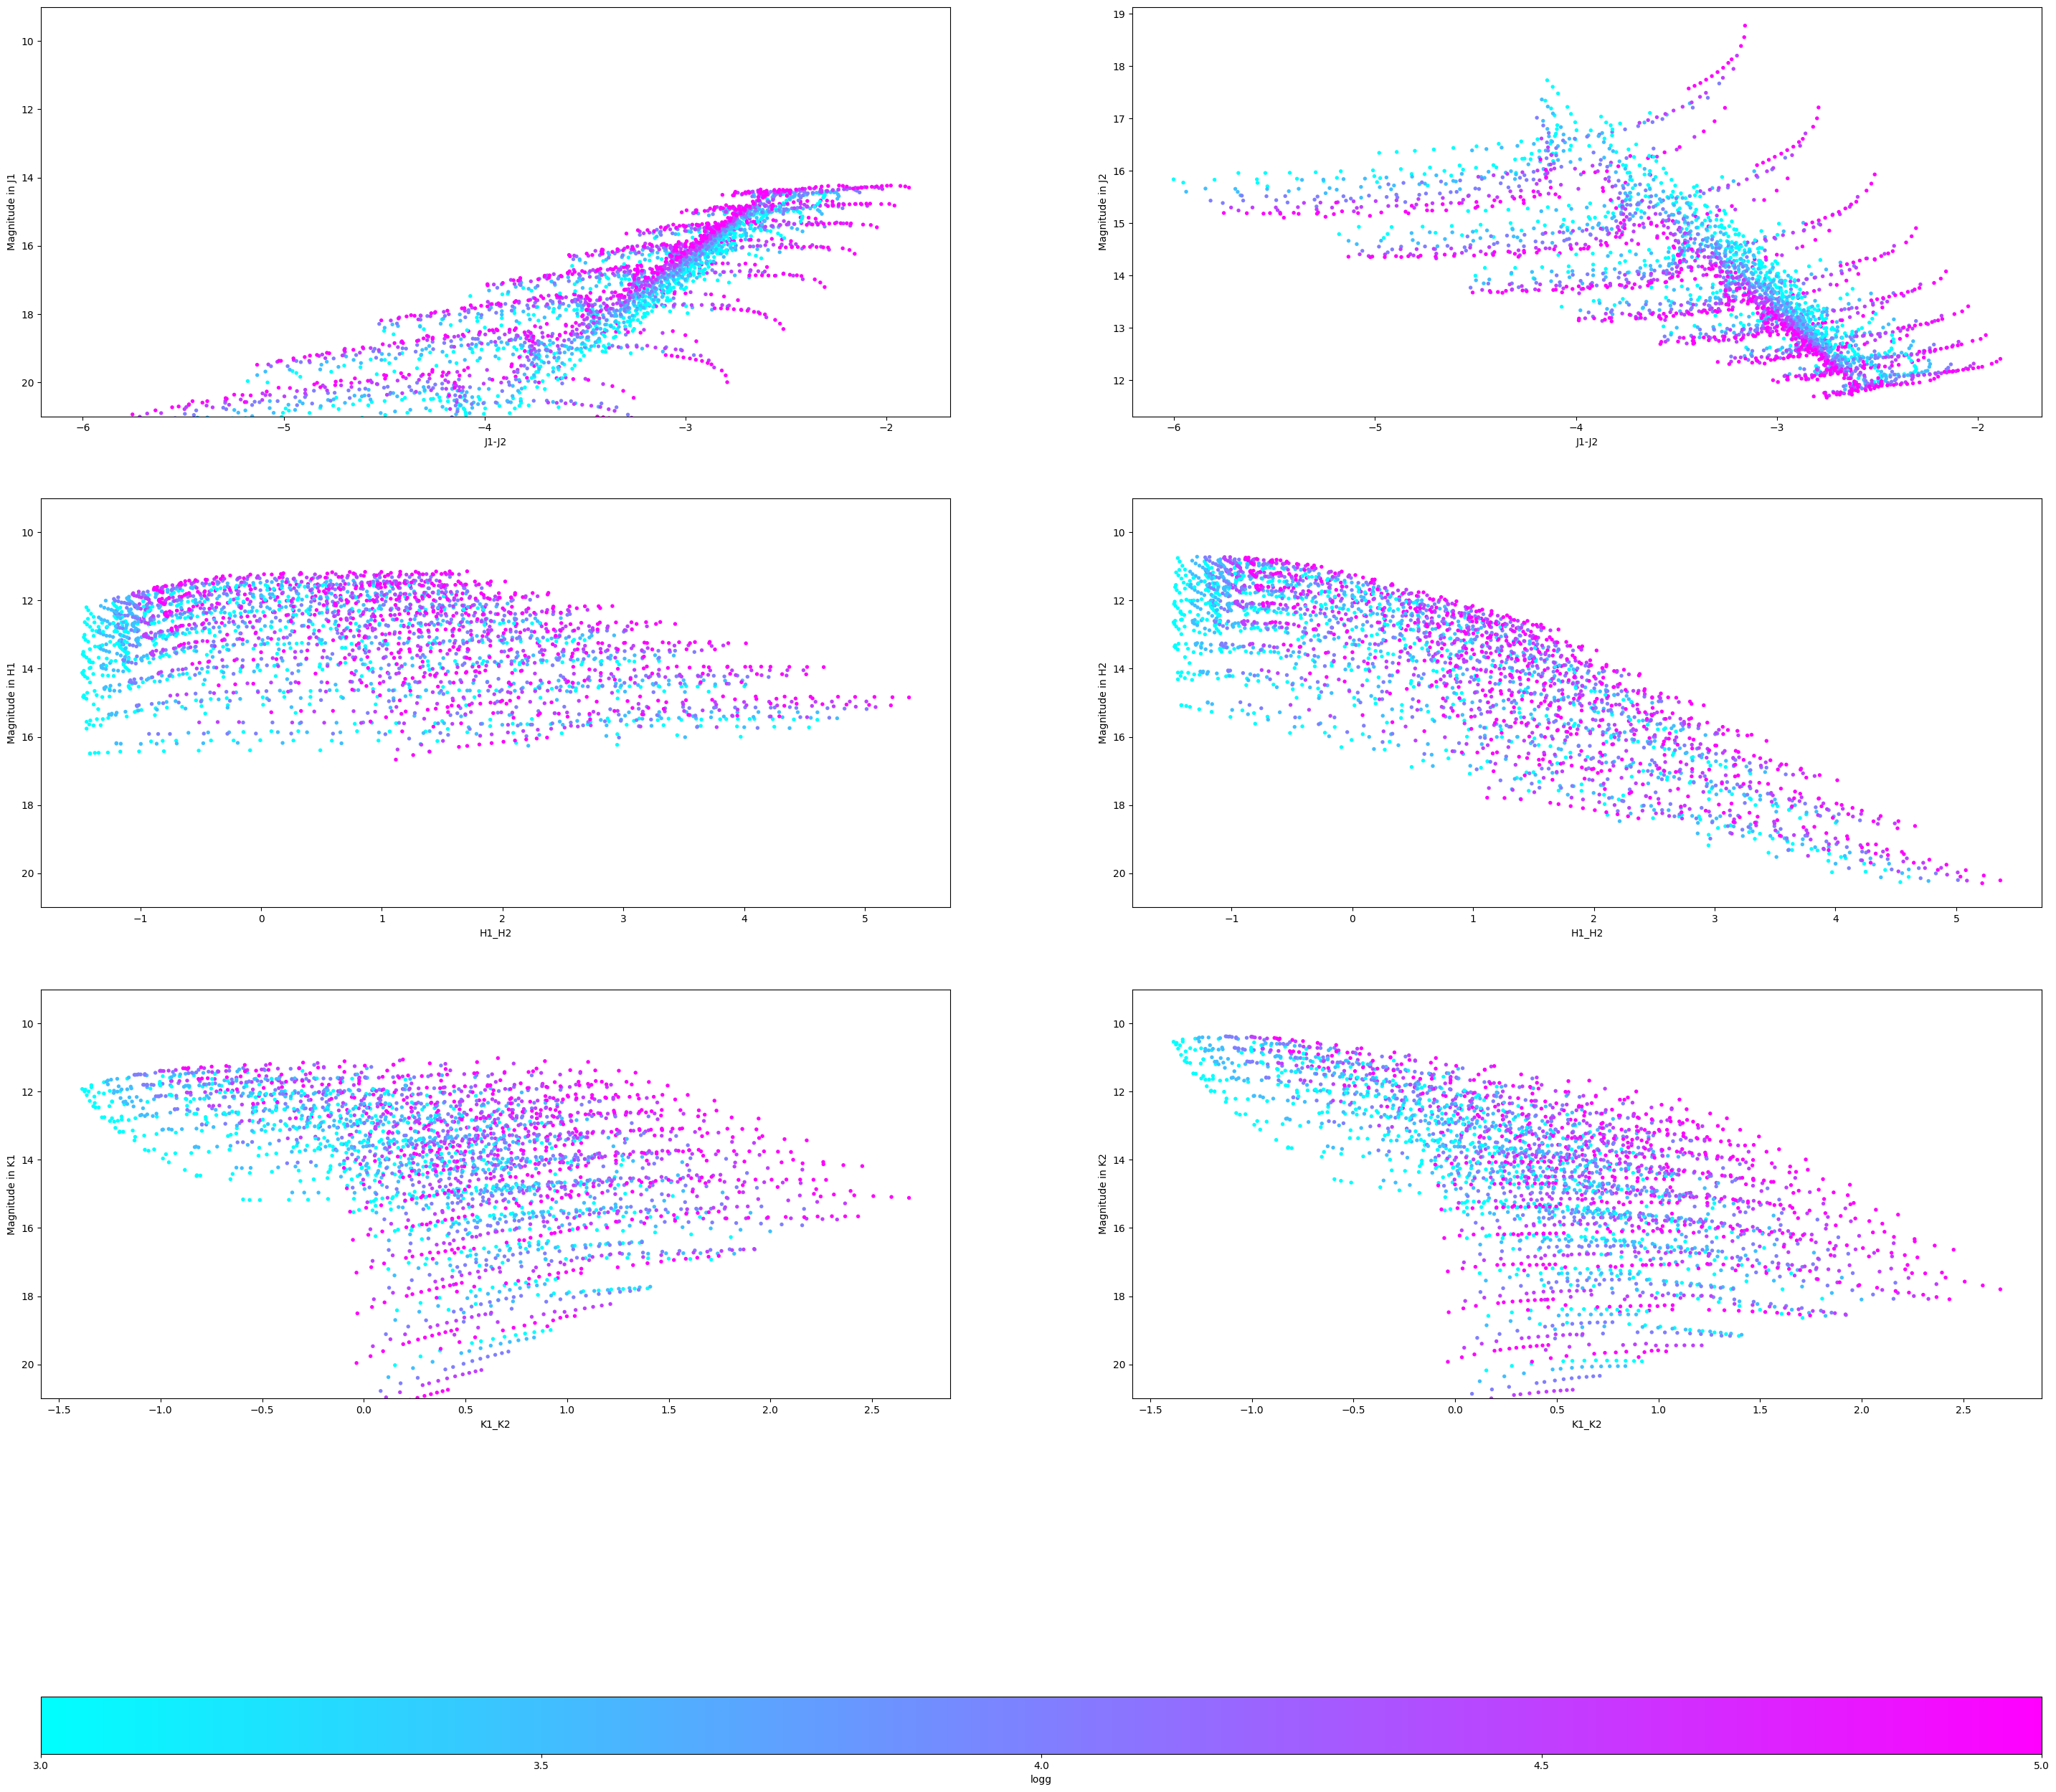

In [24]:
# Color - magnitude plots J1- J2, H1-H2, K1-K2
#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig, ax = plt.subplots(3, 2, figsize = (36,36), sharey=False)


spec_dir = 'C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/'
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
#met = 0.32
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
#logg = 3.5
#CO = 0.45

CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
temp = np.arange(400, 800, 50)
r_pl    = 1
dist_pc = 39.4

color_code = logg

n = len(color_code)

#if color_code == temp.all() :
# colors = plt.cm.plasma(np.linspace(0,1,n))
# c = np.array(color_code)
# norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
# cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.plasma)
# cmap.set_array([])
# idx = i

#if color_code == CO :
# colors = plt.cm.viridis(np.linspace(0,1,n))
# c = np.array(color_code)
# norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
# cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
# cmap.set_array([])
# idx = l

# if color_code == logg :
colors = plt.cm.cool(np.linspace(0,1,n))
c = np.array(color_code)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cool)
cmap.set_array([])
idx = j

# if color_code == metallicity:
# colors = plt.cm.copper_r(np.linspace(0,1,n))
# norm = mpl.colors.LogNorm(vmin=c.min(), vmax=c.max())
# cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.copper_r)
# cmap.set_array([])
# idx = k

#need to index flux_zero to get the correct flux wavelengths
planet_mag_J = []
planet_mag_H = []
planet_mag_K = []
lbd_midband = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220]
lbd_broadband =  [1.245 , 1.635, 2.145]


flux_zero   = fits.getdata(flux_dir+'Zero_mag_in_phot_per_m2_per_um_per_s.fits')

#print(flux_zero)
#planet_mag_broad_list = []
for i in range(len(temp)) :
    for j in range(len(logg)):
        for k in range(len(metallicity)):
            for l in range(len(CO)):
                #print ('indexes :', i, j, k, l)
                #print('temp = ', temp[i], 'logg = ', logg[j], 'met = ', metallicity[k], 'CO =', CO[l])
                if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg[j]}_met{metallicity[k]}_CO{CO[l]}.dat' != 0:
                    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, 
                                                flux_dir=flux_dir) # if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg}_met{metallicity}_CO{CO}.dat' != 0]

                else : 
                    continue
                
                planet_mag_J1 = []
                planet_mag_H1 = []
                planet_mag_K1 = []
                planet_mag_J2 = []
                planet_mag_H2 = []
                planet_mag_K2 = []
                flux_ref =[]

                for n in range(len(lbd_midband)):
                    if lbd_midband[n] == 1.190:
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.245]
                        #print('flux ref J =', flux_ref)
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0])
                        #print('flux ratio J =', flux_ratio)                      
                        planet_mag_J1.append(-2.5*math.log(flux_ratio, 10))# if i != 0]
                        #planet_mag_J.append(-2.5*math.log(planet_photon_flux))

                    if lbd_midband[n] == 1.270  :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)

                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 1.635]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0])                
                        #print('flux ref H =', flux_ref)
                        #print('flux ratio H =', flux_ratio)
                        planet_mag_J2.append(-2.5*math.log(flux_ratio, 10))
                        # planet_mag_H = [-2.5*math.log(planet_photon_flux/flux_ref)]# if i != 0]

                    if lbd_midband[n] ==1.582 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0]) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_H1.append(-2.5*math.log(flux_ratio, 10))

                    if lbd_midband[n] ==1.693 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0]) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_H2.append(-2.5*math.log(flux_ratio, 10))

                    if lbd_midband[n] == 2.100:
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0]) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_K1.append(-2.5*math.log(flux_ratio, 10))

                    if lbd_midband[n] == 2.220 :
                        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                                planet_flux, f'{lbd_midband[n]:5.3f}', 
                                                                                frame_exp_time, telescope_surface, 
                                                                                airmass=airmass, pixel_scale=pixscale_in_mas)
                        
                        flux_ref = [flux_zero[x] for x in range(len(spec_wave)) if spec_wave[x] == 2.145]
                        flux_ratio = np.float32(planet_photon_flux/flux_ref[0]) 
                        #print('planet_photon_flux =', planet_photon_flux)
                        #print('flux_ratio K =', flux_ratio)
                        #print('flux ratio K =', flux_ratio)                    
                        planet_mag_K2.append(-2.5*math.log(flux_ratio, 10))

                J1_J2 = -(np.array(planet_mag_J1) - np.array(planet_mag_J2))
                H1_H2 = -(np.array(planet_mag_H1) - np.array(planet_mag_H2))
                K1_K2 = -(np.array(planet_mag_K1) - np.array(planet_mag_K2))
                

                ax[0][0].scatter(J1_J2, planet_mag_J1, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[0][0].set_xlabel('J1-J2')
                ax[0][0].set_ylabel('Magnitude in J1')
                ax[0][0].set_ylim(21,9)
                ax[1][0].scatter(H1_H2, planet_mag_H1, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[1][0].set_xlabel('H1_H2')
                ax[1][0].set_ylabel('Magnitude in H1')
                ax[1][0].set_ylim(21,9)
                ax[2][0].scatter(K1_K2, planet_mag_K1, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[2][0].set_xlabel('K1_K2')
                ax[2][0].set_ylabel('Magnitude in K1')
                ax[2][0].set_ylim(21,9)
                
                ax[0][1].scatter(J1_J2, planet_mag_J2, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[0][1].set_xlabel('J1-J2')
                ax[0][1].set_ylabel('Magnitude in J2')
                #ax[0][1].set_ylim(21,9)
                ax[1][1].scatter(H1_H2, planet_mag_H2, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[1][1].set_xlabel('H1_H2')
                ax[1][1].set_ylabel('Magnitude in H2')
                ax[1][1].set_ylim(21,9)
                ax[2][1].scatter(K1_K2, planet_mag_K2, color = colors[j], s=15, edgecolor='none', label='planet_mag', zorder=1)
                ax[2][1].set_xlabel('K1_K2')
                ax[2][1].set_ylabel('Magnitude in K2')
                ax[2][1].set_ylim(21,9)
#plt.title('Color-magnitude diagram of planets by CO')
plt.colorbar(cmap, ax = ax, location = 'bottom', orientation = 'horizontal', aspect = 35, label = 'logg', ticks = color_code)
plt.savefig('D:/FROM_RED/flux_and_contrasts/'+ f'Mag narrow bands color coded by logg')
plt.show()